# 01 — Data Understanding

## E-Commerce Risk & Demand Intelligence System

**Scope of this notebook:** exploration only.

This notebook inspects `nigeria_ecommerce_major_project_25000.csv` as-is. It does **not**:

- train any model,
- permanently clean or overwrite the source data,
- drop rows,
- engineer or encode features,
- assume what the cancellation target or feature set will be.

Any parsed/derived columns created below (e.g. a datetime version of `order_timestamp`) exist only in memory for this notebook and are not written back to the CSV.

Decisions about targets, leakage rules, and modeling strategy are owned by the project's engineer and are **not** made in this notebook. The final section lists open questions that must be resolved before any modeling work begins.


## 1. Imports and Data Load

We load the CSV using a project-relative path (no hard-coded absolute paths), so the notebook works whether it is run from the repository root or from within `notebook/`.


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

input_root = Path("/kaggle/input")
target_file = "nigeria_ecommerce_major_project_25000.csv"

if not input_root.exists():
    raise RuntimeError(
        "This cell must run on Kaggle, not the local VS Code kernel. "
        "Push the notebook with 'kaggle kernels push -p .' and run it on Kaggle."
    )

dataset_path = next(input_root.rglob(target_file), None)

if dataset_path is None:
    raise FileNotFoundError(
        f"{target_file} was not found under {input_root}. "
        "Confirm that the Kaggle dataset is attached to this Kernel."
    )

print(f"Using Kaggle dataset: {dataset_path}")
df = pd.read_csv(dataset_path)
df.head()

In [ ]:
# Imports and reproducibility setup
from pathlib import Path
import json
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")


df = pd.read_csv("../data/nigeria_ecommerce_25000.csv")

print("Shape:", df.shape)
display(df.head())

Shape: (25000, 31)


,order_id,customer_id,order_timestamp,order_date,city,customer_type,customer_tenure_days,previous_orders,prior_cancellations,email_verified,traffic_source,device_type,session_duration_minutes,pages_viewed,cart_items,product,category,quantity,unit_price,discount_percent,coupon_code,shipping_fee,delivery_distance_km,estimated_delivery_days,payment_method,gross_amount,discount_amount,total_amount,order_status,actual_delivery_days,customer_rating
0,1,13681,2024-03-06 05:49:07,2024-03-06,Ilorin,New,6,0,0,True,Affiliate,Mobile,4.20,6,1,T-Shirt,Fashion,1,"8,500.00",10,FLASH15,"1,900.00",25.40,4,Card,"8,500.00",850.00,"9,550.00",Delivered,5.00,4.00
1,2,12075,2025-07-19 18:17:04,2025-07-19,Benin City,Returning,402,14,0,True,Organic,Mobile,8.30,6,6,Air Fryer,Home & Kitchen,4,"66,200.00",10,SAVE5,"1,900.00",25.40,5,Card,"264,800.00","26,480.00","240,220.00",Delivered,7.00,4.00
2,3,10402,2025-04-23 11:48:09,2025-04-23,Abuja,Returning,221,5,0,True,Email,Mobile,9.10,4,2,Smart Watch,Electronics,1,"54,600.00",0,NaN,"2,500.00",38.30,5,Bank Transfer,"54,600.00",0.00,"57,100.00",Delivered,6.00,4.00
3,4,10764,2024-11-16 19:40:59,2024-11-16,Port Harcourt,Returning,178,13,1,False,Referral,Mobile,45.80,15,3,Cookware Set,Home & Kitchen,3,"79,600.00",5,FLASH15,"2,100.00",28.60,5,Cash on Delivery,"238,800.00","11,940.00","228,960.00",Delivered,6.00,3.00
4,5,11214,2024-11-12 12:49:09,2024-11-12,Port Harcourt,New,82,0,0,True,Social Media,Mobile,8.40,10,4,T-Shirt,Fashion,1,"11,600.00",10,SAVE10,"2,400.00",34.90,5,Bank Transfer,"11,600.00","1,160.00","12,840.00",Cancelled,NaN,NaN


## 2. Dataframe Shape


In [2]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 25,000
Columns: 31


**Why this matters:** confirms the file loaded correctly and matches the expected row/column count documented for this dataset. A mismatch here (e.g. far fewer rows than expected) is an early signal of a truncated file, a wrong delimiter, or an encoding issue — all of which must be resolved before any further analysis is trusted.


## 3. First 10 Rows and a Fixed-Seed Random Sample


In [3]:
display(df.head(10))

,order_id,customer_id,order_timestamp,order_date,city,customer_type,customer_tenure_days,previous_orders,prior_cancellations,email_verified,...,shipping_fee,delivery_distance_km,estimated_delivery_days,payment_method,gross_amount,discount_amount,total_amount,order_status,actual_delivery_days,customer_rating
0,1,13681,2024-03-06 05:49:07,2024-03-06,Ilorin,New,6,0,0,True,...,1900.0,25.4,4,Card,8500.0,850.0,9550.0,Delivered,5.0,4.0
1,2,12075,2025-07-19 18:17:04,2025-07-19,Benin City,Returning,402,14,0,True,...,1900.0,25.4,5,Card,264800.0,26480.0,240220.0,Delivered,7.0,4.0
2,3,10402,2025-04-23 11:48:09,2025-04-23,Abuja,Returning,221,5,0,True,...,2500.0,38.3,5,Bank Transfer,54600.0,0.0,57100.0,Delivered,6.0,4.0
3,4,10764,2024-11-16 19:40:59,2024-11-16,Port Harcourt,Returning,178,13,1,False,...,2100.0,28.6,5,Cash on Delivery,238800.0,11940.0,228960.0,Delivered,6.0,3.0
4,5,11214,2024-11-12 12:49:09,2024-11-12,Port Harcourt,New,82,0,0,True,...,2400.0,34.9,5,Bank Transfer,11600.0,1160.0,12840.0,Cancelled,NaN,NaN
5,6,12032,2025-09-19 15:14:29,2025-09-19,Lagos,New,22,0,0,True,...,2300.0,28.4,4,Bank Transfer,15800.0,3160.0,14940.0,Cancelled,NaN,NaN
6,7,14430,2024-03-03 19:49:48,2024-03-03,Benin City,New,43,0,0,True,...,1700.0,19.5,3,Card,36900.0,9225.0,29375.0,Delivered,3.0,4.0
7,8,10598,2025-05-24 18:37:28,2025-05-24,Ibadan,Returning,892,5,1,True,...,2200.0,30.1,4,Card,17200.0,3440.0,15960.0,Cancelled,NaN,NaN
8,9,12885,2024-05-27 06:34:53,2024-05-27,Ibadan,Returning,157,12,1,True,...,2100.0,28.1,3,Bank Transfer,23000.0,1150.0,23950.0,Delivered,6.0,4.0
9,10,11737,2024-03-09 20:14:50,2024-03-09,Lagos,VIP,758,38,0,True,...,1800.0,17.3,3,Bank Transfer,23100.0,5775.0,19125.0,Delivered,3.0,4.0


In [4]:
display(df.sample(n=5, random_state=42))

,order_id,customer_id,order_timestamp,order_date,city,customer_type,customer_tenure_days,previous_orders,prior_cancellations,email_verified,...,shipping_fee,delivery_distance_km,estimated_delivery_days,payment_method,gross_amount,discount_amount,total_amount,order_status,actual_delivery_days,customer_rating
6868,6869,11573,2025-06-30 10:16:31,2025-06-30,Ibadan,Returning,109,4,0,True,...,2600.0,39.4,4,Card,13400.0,670.0,15330.0,Cancelled,NaN,NaN
24016,24017,14180,2025-07-12 06:08:56,2025-07-12,Ibadan,Returning,879,3,0,False,...,2500.0,38.3,4,Card,125700.0,37710.0,90490.0,Cancelled,NaN,NaN
9668,9669,10135,2024-05-08 19:44:20,2024-05-08,Ibadan,Returning,766,14,0,True,...,1500.0,14.6,3,Card,46600.0,6990.0,41110.0,Cancelled,NaN,NaN
13640,13641,11237,2025-04-26 04:10:03,2025-04-26,Lagos,New,80,1,0,True,...,1100.0,1.0,3,Bank Transfer,178800.0,17880.0,162020.0,Delivered,4.0,5.0
14018,14019,13265,2025-01-21 04:21:47,2025-01-21,Kano,Returning,644,8,0,True,...,2200.0,31.9,5,Card,17400.0,0.0,19600.0,Delivered,7.0,5.0


**Why this matters:** `head()` shows the data in its natural order, which can hide problems that only appear later in the file (e.g. a batch of rows from a different source or time period). A fixed-seed random sample (`random_state=42`) gives a second, reproducible look at rows from anywhere in the file, and lets anyone re-running this notebook see exactly the same sample rows for discussion.


## 4. Column Names and Data Types


In [5]:
dtypes_df = df.dtypes.rename("dtype").to_frame()
dtypes_df["column"] = dtypes_df.index
dtypes_df = dtypes_df[["column", "dtype"]].reset_index(drop=True)
display(dtypes_df)

,column,dtype
0,order_id,int64
1,customer_id,int64
2,order_timestamp,str
3,order_date,str
4,city,str
5,customer_type,str
6,customer_tenure_days,int64
7,previous_orders,int64
8,prior_cancellations,int64
9,email_verified,object


**Why this matters:** pandas infers types on load, and it frequently gets this wrong for real-world CSVs — dates and timestamps load as plain strings (`object`), and numeric-looking IDs can load as integers when they should be treated as categorical labels. This table is the reference point for deciding, in a later and separate step, which columns need explicit conversion before any modeling. No conversions are applied here except the read-only datetime check in Section 9.


## 5. Missing Values — Count and Percentage per Column


In [6]:
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

missing_summary = pd.DataFrame(
    {
        "missing_count": missing_count,
        "missing_percent": missing_pct,
    }
).sort_values("missing_count", ascending=False)

display(missing_summary)

,missing_count,missing_percent
customer_rating,8712,34.85
actual_delivery_days,8351,33.40
coupon_code,7431,29.72
session_duration_minutes,195,0.78
email_verified,94,0.38
order_date,0,0.00
order_id,0,0.00
customer_tenure_days,0,0.00
customer_type,0,0.00
prior_cancellations,0,0.00


**Why this matters:** missing-value patterns inform imputation strategy later, but more importantly they can reveal _why_ a value is missing (e.g. a field that is only populated after delivery, which would make it unavailable at prediction time — a leakage concern, not just a missing-data concern). No rows or columns are dropped in this notebook; this is observation only.


## 6. Duplicate Rows and Duplicate `order_id` Values


In [7]:
exact_duplicate_rows = df.duplicated(keep=False)
print(f"Exact duplicate rows (all columns identical): {exact_duplicate_rows.sum():,}")

if exact_duplicate_rows.sum() > 0:
    display(df[exact_duplicate_rows].sort_values(list(df.columns)).head(20))

Exact duplicate rows (all columns identical): 0


In [8]:
if "order_id" in df.columns:
    duplicate_order_id_mask = df["order_id"].duplicated(keep=False)
    n_duplicate_order_ids = df.loc[duplicate_order_id_mask, "order_id"].nunique()
    print(f"Rows sharing a duplicated order_id: {duplicate_order_id_mask.sum():,}")
    print(f"Distinct order_id values that repeat: {n_duplicate_order_ids:,}")

    if duplicate_order_id_mask.sum() > 0:
        display(df[duplicate_order_id_mask].sort_values("order_id").head(20))
else:
    print(
        "Column 'order_id' not found in this dataset — cannot check order_id duplication."
    )

Rows sharing a duplicated order_id: 0
Distinct order_id values that repeat: 0


**Why this matters:** this is the identifier-integrity check that determines what a single row actually represents (see the open question in the final section). If `order_id` repeats, one row is _not_ one order — it may be one order line/item, which changes how the cancellation and quantity prediction targets must be defined. Exact full-row duplicates are separately checked because they can indicate an accidental double-export or ETL bug rather than a legitimate repeated order.


## 7. Descriptive Statistics — Numerical Columns


In [9]:
numeric_df = df.select_dtypes(include=[np.number])
print(f"Numeric columns detected: {list(numeric_df.columns)}")
display(numeric_df.describe().T)

Numeric columns detected: ['order_id', 'customer_id', 'customer_tenure_days', 'previous_orders', 'prior_cancellations', 'session_duration_minutes', 'pages_viewed', 'cart_items', 'quantity', 'unit_price', 'discount_percent', 'shipping_fee', 'delivery_distance_km', 'estimated_delivery_days', 'gross_amount', 'discount_amount', 'total_amount', 'actual_delivery_days', 'customer_rating']


,count,mean,std,min,25%,50%,75%,max
order_id,25000.0,12500.500000,7217.022701,1.0,6250.75,12500.5,18750.25,25000.0
customer_id,25000.0,12505.314320,1448.331170,10001.0,11245.00,12514.5,13761.00,15000.0
customer_tenure_days,25000.0,300.479680,325.911903,0.0,47.00,106.0,536.00,1499.0
previous_orders,25000.0,5.763440,7.958066,0.0,1.00,2.0,9.00,44.0
prior_cancellations,25000.0,0.352600,0.731119,0.0,0.00,0.0,0.00,8.0
session_duration_minutes,24805.0,13.142016,8.489417,1.0,6.90,11.3,17.50,72.1
pages_viewed,25000.0,7.587120,2.929238,1.0,5.00,7.0,9.00,24.0
cart_items,25000.0,3.948760,1.647957,1.0,3.00,4.0,5.00,11.0
quantity,25000.0,2.446560,1.218065,1.0,2.00,2.0,3.00,8.0
unit_price,25000.0,28971.768000,16763.153137,5400.0,16400.00,26100.0,37500.00,99700.0


**Why this matters:** min/max/percentiles surface implausible values early (e.g. zero or negative `quantity`/`unit_price`, a `discount_percent` outside 0–100). These are candidates for a future, explicitly-logged cleaning decision — not something to silently fix now. Large gaps between the 75th percentile and the max are also a first signal for outliers that need business judgment (legitimate bulk order vs. data error), not automatic removal.


## 8. `order_status` — Unique Values and Counts


In [10]:
if "order_status" in df.columns:
    status_counts = df["order_status"].value_counts(dropna=False)
    status_pct = (
        df["order_status"].value_counts(normalize=True, dropna=False) * 100
    ).round(2)

    status_summary = pd.DataFrame(
        {
            "count": status_counts,
            "percent": status_pct,
        }
    )
    display(status_summary)
else:
    print("Column 'order_status' not found in this dataset.")

,count,percent
order_status,,
Delivered,16649,66.60
Cancelled,7659,30.64
Refunded,692,2.77


**Why this matters:** this is the raw material for the cancellation target — but the target itself is **not** defined here. In particular, note whether a `Refunded` (or similarly named) category exists alongside `Cancelled` and `Delivered`. How refunded orders should be labeled is explicitly listed as an open question below and must be decided by the senior ML engineer before any target column is created.


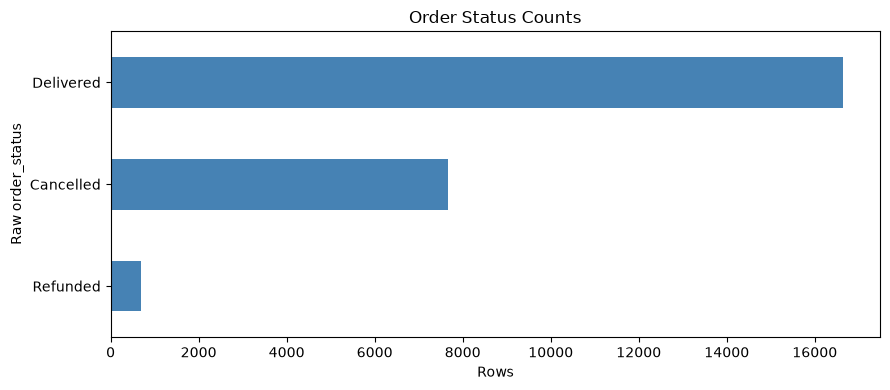

Rows in Cancelled-vs-Delivered comparison: 24308
Other/missing statuses excluded from that comparison:


,rows
order_status,
Refunded,692


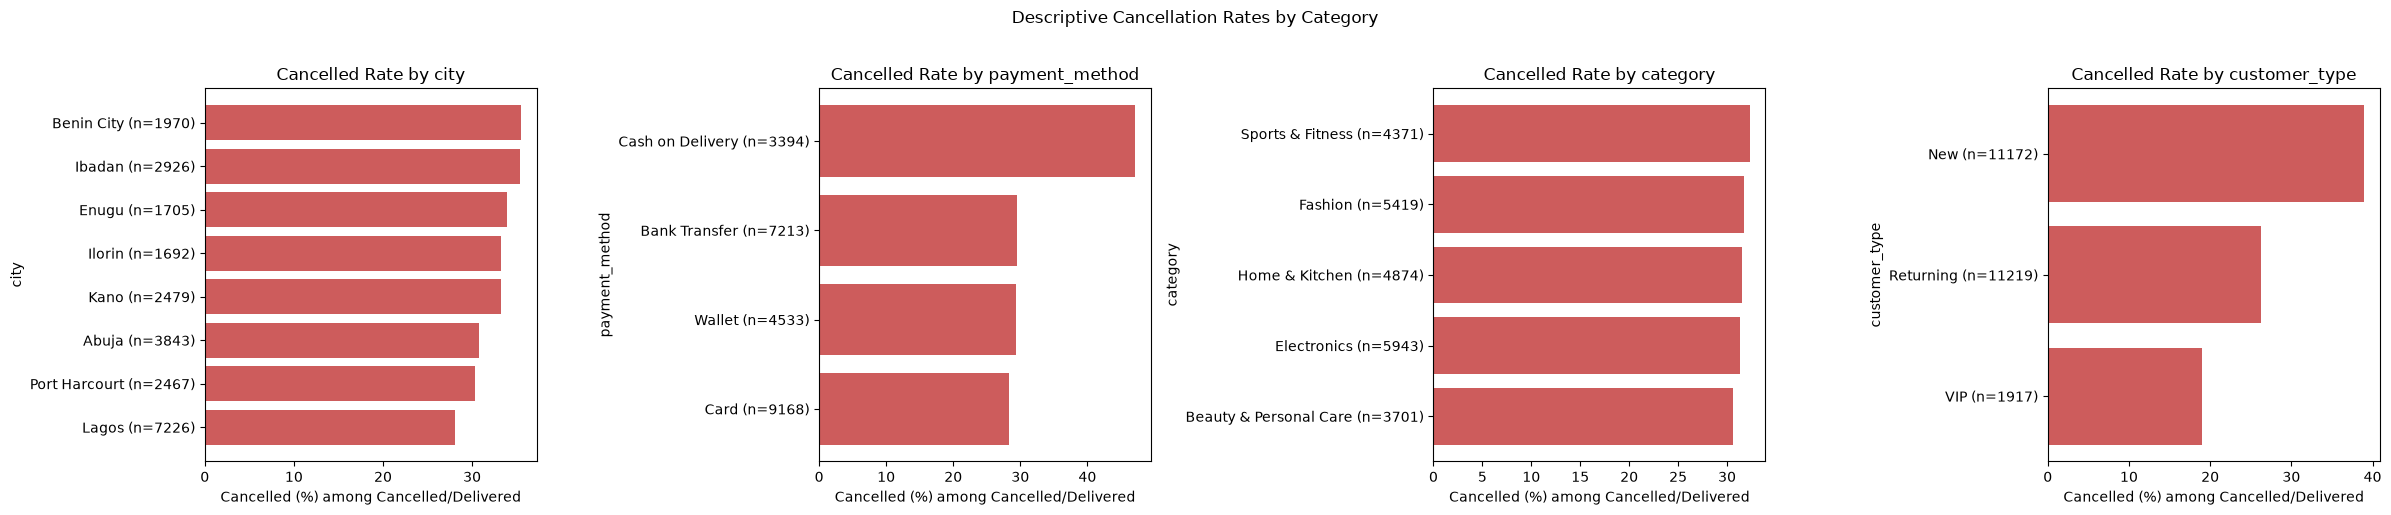

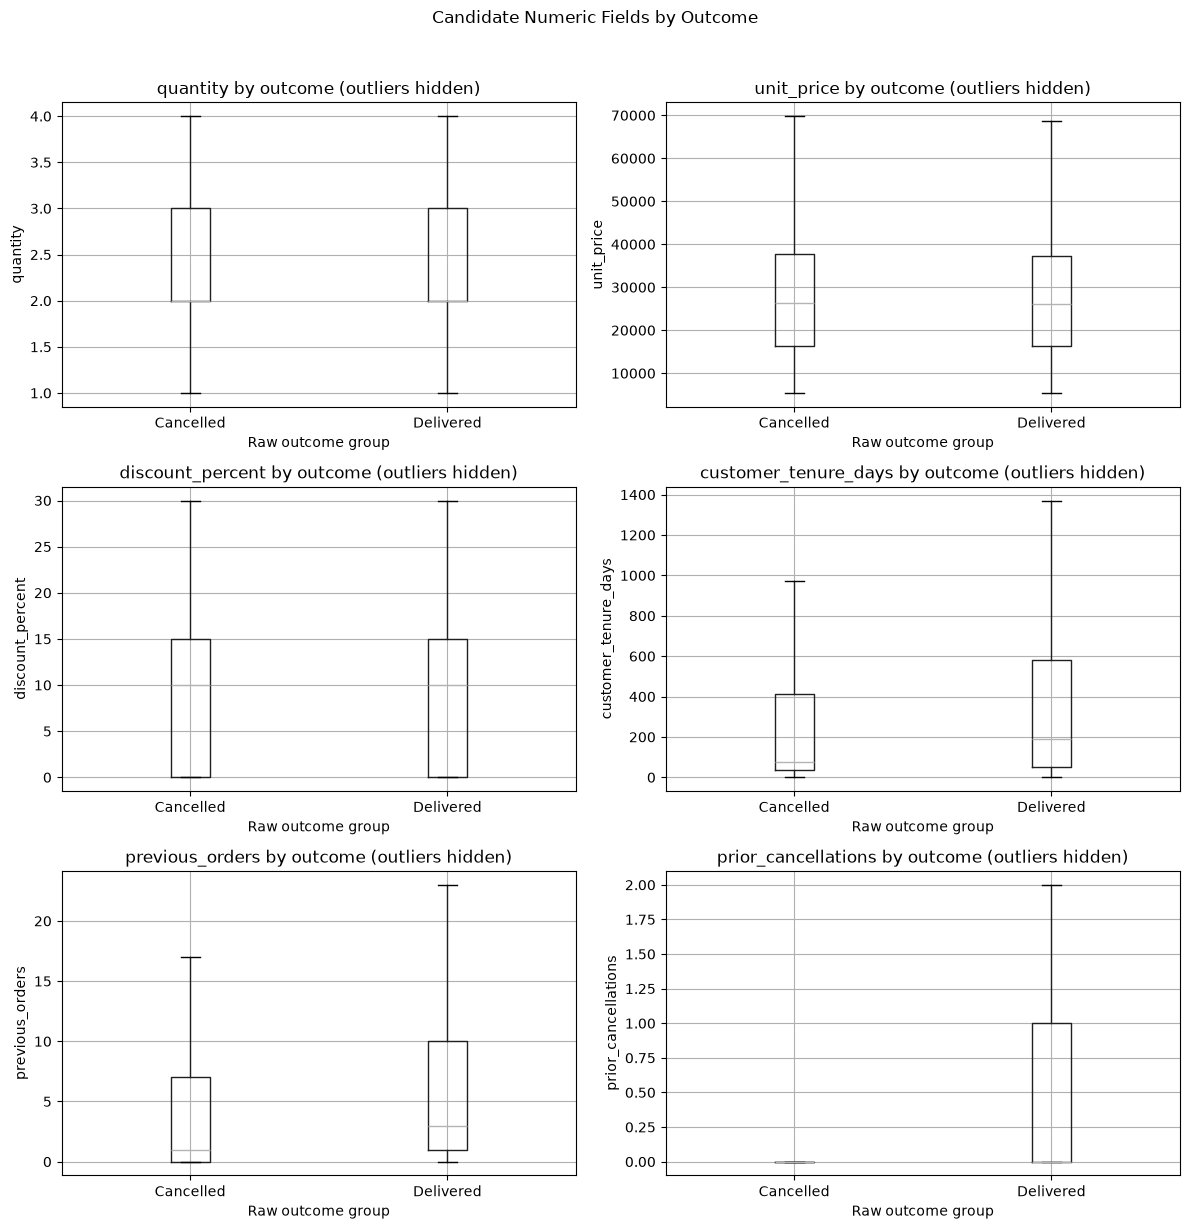

In [ ]:
# Cancellation prediction: exploratory outcome and candidate-feature checks
# These plots are descriptive only. Refunded/other statuses are reported but
# excluded from the Cancelled-vs-Delivered comparisons; no modeling target is created.
import matplotlib.pyplot as plt

status_values = df["order_status"].fillna("<missing>").astype(str).str.strip()
status_counts = status_values.value_counts(dropna=False)

fig, ax = plt.subplots(figsize=(9, 4))
status_counts.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Order Status Counts")
ax.set_xlabel("Rows")
ax.set_ylabel("Raw order_status")
plt.tight_layout()
plt.show()

normalized_status = df["order_status"].astype("string").str.strip().str.casefold()
comparison_mask = normalized_status.isin(["cancelled", "delivered"])
cancellation_view = df.loc[comparison_mask].copy()
cancellation_view["_status_for_plot"] = normalized_status.loc[comparison_mask].map(
    {"cancelled": "Cancelled", "delivered": "Delivered"}
)

excluded_statuses = status_values.loc[~comparison_mask].value_counts(dropna=False)
print("Rows in Cancelled-vs-Delivered comparison:", len(cancellation_view))
print("Other/missing statuses excluded from that comparison:")
display(excluded_statuses.to_frame("rows"))

categorical_candidates = [
    column
    for column in ["city", "payment_method", "category", "customer_type"]
    if column in cancellation_view.columns
]
if categorical_candidates and not cancellation_view.empty:
    cancellation_view["_is_cancelled_for_plot"] = (
        cancellation_view["_status_for_plot"] == "Cancelled"
    ).astype(int)
    fig, axes = plt.subplots(
        1,
        len(categorical_candidates),
        figsize=(6 * len(categorical_candidates), 5),
        squeeze=False,
    )
    for ax, column in zip(axes[0], categorical_candidates):
        grouped = cancellation_view.groupby(column, dropna=False).agg(
            cancellation_rate=("_is_cancelled_for_plot", "mean"),
            rows=("_is_cancelled_for_plot", "size"),
        )
        grouped = grouped.sort_values("cancellation_rate", ascending=True)
        labels = [
            f"{value} (n={count})"
            for value, count in zip(grouped.index, grouped["rows"])
        ]
        ax.barh(labels, grouped["cancellation_rate"] * 100, color="indianred")
        ax.set_title(f"Cancelled Rate by {column}")
        ax.set_xlabel("Cancelled (%) among Cancelled/Delivered")
        ax.set_ylabel(column)
    fig.suptitle("Descriptive Cancellation Rates by Category", y=1.02)
    plt.tight_layout()
    plt.show()

numeric_candidates = [
    column
    for column in [
        "quantity",
        "unit_price",
        "discount_percent",
        "customer_tenure_days",
        "previous_orders",
        "prior_cancellations",
    ]
    if column in cancellation_view.columns
    and pd.api.types.is_numeric_dtype(cancellation_view[column])
]
if numeric_candidates and not cancellation_view.empty:
    ncols = 2
    nrows = (len(numeric_candidates) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows), squeeze=False)
    for ax, column in zip(axes.flat, numeric_candidates):
        cancellation_view.boxplot(
            column=column, by="_status_for_plot", ax=ax, showfliers=False
        )
        ax.set_title(f"{column} by outcome (outliers hidden)")
        ax.set_xlabel("Raw outcome group")
        ax.set_ylabel(column)
    for ax in axes.flat[len(numeric_candidates) :]:
        ax.set_visible(False)
    fig.suptitle("Candidate Numeric Fields by Outcome", y=1.02)
    plt.tight_layout()
    plt.show()

## 9. `order_timestamp` — Safe Datetime Conversion (Read-Only Check)


In [11]:
if "order_timestamp" in df.columns:
    parsed_timestamps = pd.to_datetime(df["order_timestamp"], errors="coerce")

    n_unparseable = parsed_timestamps.isna().sum() - df["order_timestamp"].isna().sum()
    n_unparseable = max(n_unparseable, 0)

    print(
        f"Original missing values in order_timestamp: {df['order_timestamp'].isna().sum():,}"
    )
    print(f"Values that failed to parse as datetime: {n_unparseable:,}")
    print(f"Earliest timestamp: {parsed_timestamps.min()}")
    print(f"Latest timestamp:   {parsed_timestamps.max()}")

    # NOTE: parsed_timestamps is a local, in-memory Series used only for this check.
    # It is intentionally NOT written back into df, to keep this notebook exploration-only.
else:
    print("Column 'order_timestamp' not found in this dataset.")

Original missing values in order_timestamp: 0
Values that failed to parse as datetime: 0
Earliest timestamp: 2024-01-01 00:00:54
Latest timestamp:   2025-12-31 23:35:47


**Why this matters:** `errors="coerce"` converts unparseable values to `NaT` instead of raising an error, so we can see _how many_ timestamps are malformed without the notebook crashing or silently guessing a format. The date range tells us how much historical coverage exists, which is directly relevant to the later (separate) question of whether any time-based feature or a temporal train/test split is feasible. This parsed series is not merged into `df`; the source dataframe is left untouched.


## Questions to Resolve Before Modeling

These are open decisions, not conclusions from this notebook. They must be resolved by the project owner in consultation with the senior ML engineer before any feature engineering, target creation, or model training begins.

1. **What does one row represent?**
   Is each row a distinct order (one `order_id` per row), an order line/item, or a customer session event? This depends directly on the `order_id` duplication check in Section 6 and determines the correct unit of prediction for both the cancellation and quantity models.

2. **How should refunded orders be defined for the cancellation target?**
   If `order_status` includes a `Refunded` category (or equivalent) alongside `Cancelled` and `Delivered`, a deliberate decision is needed: treat refunds as cancellations, as a separate third class, as delivered, or exclude them from the classification dataset entirely. This must not default silently — see Section 8.

3. **Which features are genuinely available at the moment an order is placed?**
   For every column, the question is: _was this known when the order was created?_ This must be answered column-by-column against the leakage rules already established for this project (excluding `order_status`, `actual_delivery_days`, `customer_rating`, and any quantity-derived monetary fields such as `gross_amount`, `discount_amount`, `total_amount`).

4. **Which fields are only known after an outcome happens?**
   Beyond the fields already flagged as forbidden, this dataset should be reviewed for any other post-outcome fields (e.g. delivery timing, customer feedback, payment confirmation events) that could leak information about the target if included as features.

No answers to these questions are assumed or implied elsewhere in this notebook.


In [ ]:
# MODEL B — DEMAND FORECASTING FEASIBILITY AUDIT
# Purpose:
# Determine whether the existing transaction dataset can support
# a defensible future-demand forecasting problem.
#
# IMPORTANT:
# - This section does NOT train any ML model.
# - It does NOT modify the original dataset.
# - It does NOT create the final forecasting target.
# - It only investigates whether Model B is feasible.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


# 0. Basic dataset verification


print("Dataset shape:", df.shape)

required_columns = [
    "order_timestamp",
    "order_date",
    "product",
    "category",
    "city",
    "quantity",
    "order_status",
]

missing_required = [col for col in required_columns if col not in df.columns]

if missing_required:
    print("\nMissing required columns:")
    print(missing_required)
else:
    print("\nAll Model B candidate columns are present.")

Dataset shape: (25000, 31)

All Model B candidate columns are present.


In [ ]:
# 1. TIME COVERAGE


model_b = df.copy()

model_b["order_timestamp"] = pd.to_datetime(model_b["order_timestamp"], errors="coerce")

model_b["order_date"] = pd.to_datetime(model_b["order_date"], errors="coerce")

print("Timestamp missing:", model_b["order_timestamp"].isna().sum())
print("Order date missing:", model_b["order_date"].isna().sum())

print("\nTimestamp range:")
print("Start:", model_b["order_timestamp"].min())
print("End:  ", model_b["order_timestamp"].max())

print("\nOrder-date range:")
print("Start:", model_b["order_date"].min())
print("End:  ", model_b["order_date"].max())

print("\nUnique calendar days:", model_b["order_date"].dt.normalize().nunique())

print("Unique weeks:", model_b["order_date"].dt.to_period("W").nunique())

print("Unique months:", model_b["order_date"].dt.to_period("M").nunique())

print("Unique years:", model_b["order_date"].dt.year.nunique())

Timestamp missing: 0
Order date missing: 0

Timestamp range:
Start: 2024-01-01 00:00:54
End:   2025-12-31 23:35:47

Order-date range:
Start: 2024-01-01 00:00:00
End:   2025-12-31 00:00:00

Unique calendar days: 731
Unique weeks: 105
Unique months: 24
Unique years: 2


In [ ]:
# 2. TEMPORAL COVERAGE / GAPS

daily_counts = (
    model_b.groupby(model_b["order_date"].dt.normalize()).size().rename("orders")
)

full_daily_index = pd.date_range(
    start=model_b["order_date"].min(), end=model_b["order_date"].max(), freq="D"
)

daily_coverage = daily_counts.reindex(full_daily_index, fill_value=0)

zero_order_days = (daily_coverage == 0).sum()

print("Expected calendar days:", len(full_daily_index))
print("Days with at least one order:", (daily_coverage > 0).sum())
print("Days with zero orders:", zero_order_days)

print("\nPercentage of calendar days with orders:", (daily_coverage > 0).mean() * 100)

Expected calendar days: 731
Days with at least one order: 731
Days with zero orders: 0

Percentage of calendar days with orders: 100.0


In [ ]:
# 3. PRODUCT-LEVEL DEMAND

product_summary = (
    model_b.groupby("product")
    .agg(
        orders=("order_timestamp", "size"),
        total_quantity=("quantity", "sum"),
        mean_quantity=("quantity", "mean"),
        median_quantity=("quantity", "median"),
        min_quantity=("quantity", "min"),
        max_quantity=("quantity", "max"),
        first_order=("order_date", "min"),
        last_order=("order_date", "max"),
    )
    .sort_values("total_quantity", ascending=False)
)

print("Number of products:", len(product_summary))

display(product_summary)

Number of products: 30


,orders,total_quantity,mean_quantity,median_quantity,min_quantity,max_quantity,first_order,last_order
product,,,,,,,,
Wireless Earbuds,1074,2526,2.35,2.00,1,7,2024-01-01,2025-12-31
Bluetooth Speaker,1039,2451,2.36,2.00,1,8,2024-01-01,2025-12-31
Laptop Stand,1055,2443,2.32,2.00,1,8,2024-01-01,2025-12-31
Phone Charger,1004,2394,2.38,2.00,1,7,2024-01-01,2025-12-31
Power Bank,1001,2359,2.36,2.00,1,6,2024-01-01,2025-12-31
Smart Watch,1020,2345,2.30,2.00,1,7,2024-01-01,2025-12-31
Dumbbell Set,810,2333,2.88,3.00,1,8,2024-01-01,2025-12-31
Backpack,966,2280,2.36,2.00,1,7,2024-01-01,2025-12-31
Sneakers,952,2269,2.38,2.00,1,8,2024-01-01,2025-12-30


In [ ]:
# 4. PRODUCT × WEEK OBSERVATIONS

model_b["week"] = model_b["order_date"].dt.to_period("W").dt.start_time

weekly_product = model_b.groupby(["week", "product"], as_index=False).agg(
    orders=("order_timestamp", "size"), quantity=("quantity", "sum")
)

product_week_summary = (
    weekly_product.groupby("product")
    .agg(
        weeks_with_demand=("week", "nunique"),
        total_orders=("orders", "sum"),
        total_quantity=("quantity", "sum"),
        mean_weekly_quantity=("quantity", "mean"),
        median_weekly_quantity=("quantity", "median"),
        first_week=("week", "min"),
        last_week=("week", "max"),
    )
    .sort_values("weeks_with_demand", ascending=False)
)

display(product_week_summary)

,weeks_with_demand,total_orders,total_quantity,mean_weekly_quantity,median_weekly_quantity,first_week,last_week
product,,,,,,,
Air Fryer,105,796,1861,17.72,17.00,2024-01-01,2025-12-29
Backpack,105,966,2280,21.71,22.00,2024-01-01,2025-12-29
Blender,105,857,2025,19.29,18.00,2024-01-01,2025-12-29
Bluetooth Speaker,105,1039,2451,23.34,23.00,2024-01-01,2025-12-29
Body Lotion,105,610,1462,13.92,13.00,2024-01-01,2025-12-29
Cookware Set,105,868,1996,19.01,18.00,2024-01-01,2025-12-29
Desk Lamp,105,863,1962,18.69,19.00,2024-01-01,2025-12-29
Dumbbell Set,105,810,2333,22.22,22.00,2024-01-01,2025-12-29
Electric Kettle,105,817,1935,18.43,18.00,2024-01-01,2025-12-29


In [ ]:
# 5. WEEKLY DEMAND SPARSITY

all_weeks = pd.date_range(
    start=model_b["week"].min(), end=model_b["week"].max(), freq="W-MON"
)

products = model_b["product"].dropna().unique()

complete_weekly_index = pd.MultiIndex.from_product(
    [all_weeks, products], names=["week", "product"]
)

weekly_demand = (
    weekly_product.set_index(["week", "product"])["quantity"]
    .reindex(complete_weekly_index, fill_value=0)
    .rename("demand")
    .reset_index()
)

weekly_sparsity = weekly_demand.groupby("product").agg(
    total_weeks=("week", "nunique"),
    nonzero_weeks=("demand", lambda x: (x > 0).sum()),
    zero_weeks=("demand", lambda x: (x == 0).sum()),
    total_demand=("demand", "sum"),
    mean_demand=("demand", "mean"),
    std_demand=("demand", "std"),
)

weekly_sparsity["nonzero_rate_percent"] = (
    weekly_sparsity["nonzero_weeks"] / weekly_sparsity["total_weeks"] * 100
)

weekly_sparsity["zero_rate_percent"] = (
    weekly_sparsity["zero_weeks"] / weekly_sparsity["total_weeks"] * 100
)

display(weekly_sparsity.sort_values("nonzero_rate_percent"))

,total_weeks,nonzero_weeks,zero_weeks,total_demand,mean_demand,std_demand,nonzero_rate_percent,zero_rate_percent
product,,,,,,,,
Hair Dryer,105,104,1,1400,13.33,6.23,99.05,0.95
Electric Trimmer,105,104,1,1435,13.67,6.04,99.05,0.95
Air Fryer,105,105,0,1861,17.72,6.95,100.00,0.00
Backpack,105,105,0,2280,21.71,8.17,100.00,0.00
Body Lotion,105,105,0,1462,13.92,6.45,100.00,0.00
Cookware Set,105,105,0,1996,19.01,7.08,100.00,0.00
Blender,105,105,0,2025,19.29,7.76,100.00,0.00
Bluetooth Speaker,105,105,0,2451,23.34,7.03,100.00,0.00
Dumbbell Set,105,105,0,2333,22.22,9.47,100.00,0.00


In [ ]:
# 6. ORDER STATUS AND QUANTITY

status_summary = (
    model_b.groupby("order_status")
    .agg(
        orders=("order_id", "size"),
        total_quantity=("quantity", "sum"),
        mean_quantity=("quantity", "mean"),
        median_quantity=("quantity", "median"),
    )
    .sort_values("orders", ascending=False)
)

status_summary["order_percentage"] = status_summary["orders"] / len(model_b) * 100

status_summary["quantity_percentage"] = (
    status_summary["total_quantity"] / model_b["quantity"].sum() * 100
)

display(status_summary)

,orders,total_quantity,mean_quantity,median_quantity,order_percentage,quantity_percentage
order_status,,,,,,
Delivered,16649,40737,2.45,2.00,66.60,66.60
Cancelled,7659,18732,2.45,2.00,30.64,30.63
Refunded,692,1695,2.45,2.00,2.77,2.77


In [ ]:
# 7. POSSIBLE DEMAND DEFINITIONS

delivered_quantity = model_b.loc[
    model_b["order_status"] == "Delivered", "quantity"
].sum()

cancelled_quantity = model_b.loc[
    model_b["order_status"] == "Cancelled", "quantity"
].sum()

refunded_quantity = model_b.loc[model_b["order_status"] == "Refunded", "quantity"].sum()

gross_requested_quantity = model_b["quantity"].sum()

print("Total requested quantity:", gross_requested_quantity)
print("Delivered quantity:      ", delivered_quantity)
print("Cancelled quantity:      ", cancelled_quantity)
print("Refunded quantity:       ", refunded_quantity)

print("\nDelivered percentage:", delivered_quantity / gross_requested_quantity * 100)

print("Cancelled percentage:", cancelled_quantity / gross_requested_quantity * 100)

print("Refunded percentage:", refunded_quantity / gross_requested_quantity * 100)

Total requested quantity: 61164
Delivered quantity:       40737
Cancelled quantity:       18732
Refunded quantity:        1695

Delivered percentage: 66.6029036688248
Cancelled percentage: 30.625858348047867
Refunded percentage: 2.77123798312733


In [ ]:
# 8. WEEKLY DEMAND TREND

weekly_total = model_b.groupby("week").agg(
    orders=("order_id", "size"), total_quantity=("quantity", "sum")
)

display(weekly_total.head())
display(weekly_total.tail())

print("\nWeekly demand statistics:")
display(weekly_total["total_quantity"].describe())

,orders,total_quantity
week,,
2024-01-01,246,614
2024-01-08,236,561
2024-01-15,246,580
2024-01-22,255,635
2024-01-29,250,609


,orders,total_quantity
week,,
2025-12-01,255,645
2025-12-08,242,597
2025-12-15,231,559
2025-12-22,251,602
2025-12-29,114,308



Weekly demand statistics:


count   105.00
mean    582.51
std      45.24
min     308.00
25%     561.00
50%     581.00
75%     606.00
max     668.00
Name: total_quantity, dtype: float64

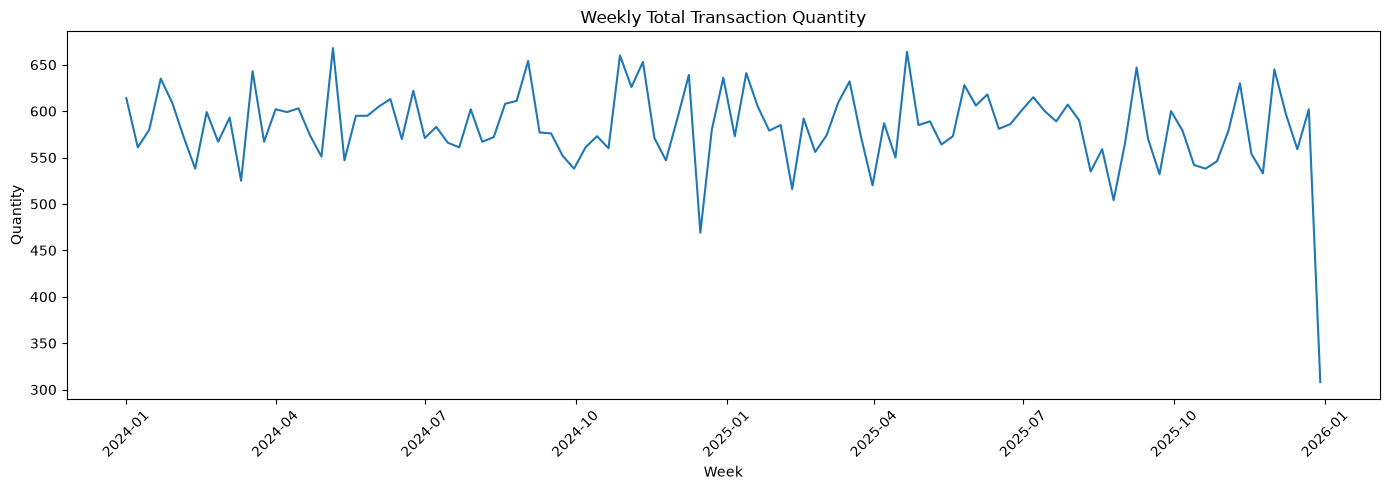

In [ ]:
# 9. WEEKLY DEMAND VISUALIZATION
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(weekly_total.index, weekly_total["total_quantity"])

plt.title("Weekly Total Transaction Quantity")
plt.xlabel("Week")
plt.ylabel("Quantity")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
# 10. MONTHLY DEMAND
# ============================================================

model_b["month"] = model_b["order_date"].dt.to_period("M").dt.to_timestamp()

monthly_total = model_b.groupby("month").agg(
    orders=("order_id", "size"), total_quantity=("quantity", "sum")
)

display(monthly_total)

,orders,total_quantity
month,,
2024-01-01,1085,2634
2024-02-01,985,2389
2024-03-01,1041,2580
2024-04-01,1050,2531
2024-05-01,1072,2630
2024-06-01,1035,2583
2024-07-01,1044,2524
2024-08-01,1087,2630
2024-09-01,1026,2510


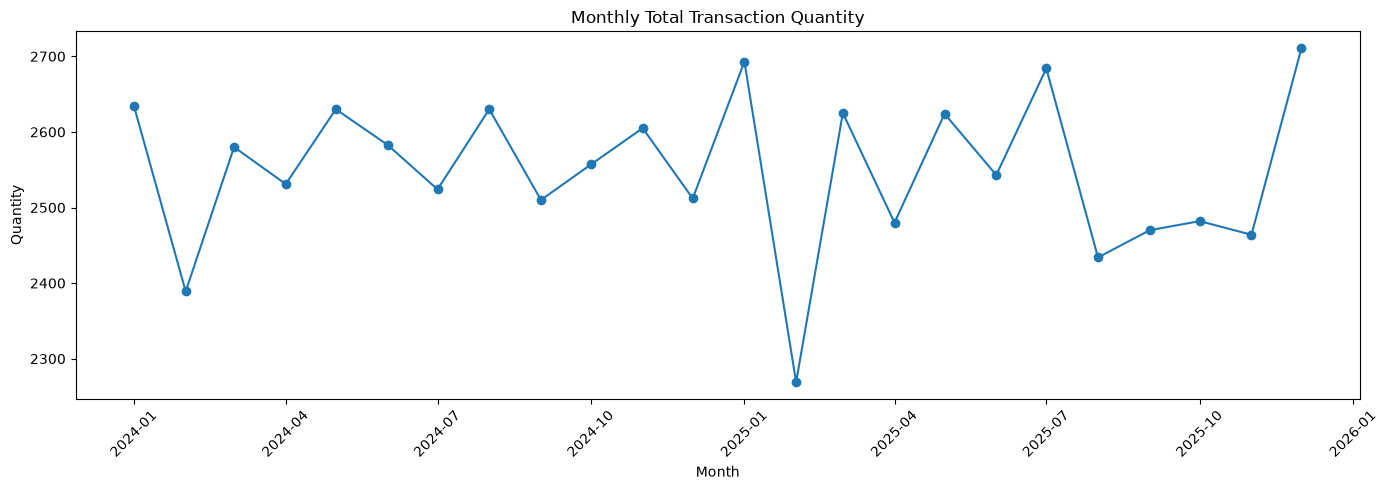

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(monthly_total.index, monthly_total["total_quantity"], marker="o")

plt.title("Monthly Total Transaction Quantity")
plt.xlabel("Month")
plt.ylabel("Quantity")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# 11. DAY-OF-WEEK PATTERN

model_b["day_of_week"] = model_b["order_date"].dt.day_name()

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

dow_summary = (
    model_b.groupby("day_of_week")
    .agg(orders=("order_id", "size"), quantity=("quantity", "sum"))
    .reindex(day_order)
)

dow_summary["average_quantity_per_order"] = (
    dow_summary["quantity"] / dow_summary["orders"]
)

display(dow_summary)

,orders,quantity,average_quantity_per_order
day_of_week,,,
Monday,3611,8758,2.43
Tuesday,3579,8752,2.45
Wednesday,3540,8806,2.49
Thursday,3605,8739,2.42
Friday,3567,8634,2.42
Saturday,3582,8806,2.46
Sunday,3516,8669,2.47


In [ ]:
# 12. MONTH-OF-YEAR PATTERN

model_b["month_number"] = model_b["order_date"].dt.month

month_summary = model_b.groupby("month_number").agg(
    orders=("order_id", "size"), quantity=("quantity", "sum")
)

month_summary["average_quantity_per_order"] = (
    month_summary["quantity"] / month_summary["orders"]
)

display(month_summary)

,orders,quantity,average_quantity_per_order
month_number,,,
1,2202,5327,2.42
2,1931,4658,2.41
3,2105,5205,2.47
4,2060,5011,2.43
5,2126,5254,2.47
6,2081,5126,2.46
7,2143,5208,2.43
8,2084,5064,2.43
9,2032,4980,2.45


In [ ]:
# 13. PRODUCT TEMPORAL COVERAGE

product_temporal = model_b.groupby("product").agg(
    first_date=("order_date", "min"),
    last_date=("order_date", "max"),
    order_count=("order_id", "size"),
    total_quantity=("quantity", "sum"),
)

product_temporal["active_days"] = (
    product_temporal["last_date"] - product_temporal["first_date"]
).dt.days + 1

product_temporal["orders_per_active_day"] = (
    product_temporal["order_count"] / product_temporal["active_days"]
)

display(product_temporal.sort_values("order_count", ascending=False))

,first_date,last_date,order_count,total_quantity,active_days,orders_per_active_day
product,,,,,,
Wireless Earbuds,2024-01-01,2025-12-31,1074,2526,731,1.47
Laptop Stand,2024-01-01,2025-12-31,1055,2443,731,1.44
Bluetooth Speaker,2024-01-01,2025-12-31,1039,2451,731,1.42
Smart Watch,2024-01-01,2025-12-31,1020,2345,731,1.40
Phone Charger,2024-01-01,2025-12-31,1004,2394,731,1.37
Power Bank,2024-01-01,2025-12-31,1001,2359,731,1.37
Backpack,2024-01-01,2025-12-31,966,2280,731,1.32
Sneakers,2024-01-01,2025-12-30,952,2269,730,1.30
Hoodie,2024-01-01,2025-12-31,911,2158,731,1.25


In [ ]:
# 14. CHRONOLOGICAL FORECASTING SPLIT FEASIBILITY

date_min = model_b["order_date"].min()
date_max = model_b["order_date"].max()

total_days = (date_max - date_min).days

print("Start:", date_min)
print("End:  ", date_max)
print("Total calendar span:", total_days, "days")

# Illustrative chronological proportions ONLY.
# These are not the final project split boundaries.
train_end = date_min + pd.Timedelta(days=round(total_days * 0.70))
validation_end = date_min + pd.Timedelta(days=round(total_days * 0.85))

train_data = model_b[model_b["order_date"] <= train_end]

validation_data = model_b[
    (model_b["order_date"] > train_end) & (model_b["order_date"] <= validation_end)
]

test_data = model_b[model_b["order_date"] > validation_end]

print("\nIllustrative chronological split:")
print("Training:", train_data["order_date"].min(), "to", train_data["order_date"].max())
print(
    "Validation:",
    validation_data["order_date"].min(),
    "to",
    validation_data["order_date"].max(),
)
print("Test:", test_data["order_date"].min(), "to", test_data["order_date"].max())

print("\nRows:")
print("Training:", len(train_data))
print("Validation:", len(validation_data))
print("Test:", len(test_data))

Start: 2024-01-01 00:00:00
End:   2025-12-31 00:00:00
Total calendar span: 730 days

Illustrative chronological split:
Training: 2024-01-01 00:00:00 to 2025-05-26 00:00:00
Validation: 2025-05-27 00:00:00 to 2025-09-12 00:00:00
Test: 2025-09-13 00:00:00 to 2025-12-31 00:00:00

Rows:
Training: 17571
Validation: 3745
Test: 3684


In [ ]:
# 15. PRODUCT COVERAGE ACROSS CHRONOLOGICAL PERIODS

for name, subset in [
    ("Training", train_data),
    ("Validation", validation_data),
    ("Test", test_data),
]:
    print(f"\n{name}")

    product_counts = subset["product"].value_counts().sort_index()

    print("Unique products:", product_counts.size)
    print(
        "Products with zero observations:",
        len(set(model_b["product"].dropna().unique()) - set(product_counts.index)),
    )

    display(product_counts)


Training
Unique products: 30
Products with zero observations: 0


product
Air Fryer            564
Backpack             717
Blender              589
Bluetooth Speaker    714
Body Lotion          429
Cookware Set         607
Desk Lamp            572
Dumbbell Set         584
Electric Kettle      561
Electric Trimmer     445
Football             525
Gym Bag              488
Hair Dryer           419
Hoodie               642
Laptop Stand         750
Makeup Kit           446
Perfume              452
Phone Charger        724
Power Bank           709
Resistance Bands     529
Running Shoes        611
Skincare Set         440
Smart Watch          735
Sneakers             683
Storage Rack         593
T-Shirt              625
Water Bottle         503
Wireless Earbuds     758
Wristwatch           681
Yoga Mat             476
Name: count, dtype: int64


Validation
Unique products: 30
Products with zero observations: 0


product
Air Fryer            129
Backpack             121
Blender              128
Bluetooth Speaker    162
Body Lotion           84
Cookware Set         131
Desk Lamp            136
Dumbbell Set         114
Electric Kettle      119
Electric Trimmer     100
Football             115
Gym Bag              128
Hair Dryer            88
Hoodie               145
Laptop Stand         164
Makeup Kit            90
Perfume              111
Phone Charger        136
Power Bank           153
Resistance Bands      96
Running Shoes        142
Skincare Set         103
Smart Watch          138
Sneakers             134
Storage Rack         119
T-Shirt              148
Water Bottle         119
Wireless Earbuds     170
Wristwatch           118
Yoga Mat             104
Name: count, dtype: int64


Test
Unique products: 30
Products with zero observations: 0


product
Air Fryer            103
Backpack             128
Blender              140
Bluetooth Speaker    163
Body Lotion           97
Cookware Set         130
Desk Lamp            155
Dumbbell Set         112
Electric Kettle      137
Electric Trimmer      79
Football             122
Gym Bag              134
Hair Dryer            93
Hoodie               124
Laptop Stand         141
Makeup Kit            95
Perfume              104
Phone Charger        144
Power Bank           139
Resistance Bands     100
Running Shoes        130
Skincare Set          98
Smart Watch          147
Sneakers             135
Storage Rack         122
T-Shirt              138
Water Bottle         109
Wireless Earbuds     146
Wristwatch           111
Yoga Mat             108
Name: count, dtype: int64

In [ ]:
# 16. FORECASTING GRANULARITY CHECK

granularity_summary = pd.DataFrame(
    {
        "Granularity": ["Daily", "Weekly", "Monthly"],
        "Total_periods": [
            model_b["order_date"].dt.normalize().nunique(),
            model_b["week"].nunique(),
            model_b["month"].nunique(),
        ],
        "Periods_with_orders": [
            model_b["order_date"].dt.normalize().nunique(),
            model_b["week"].nunique(),
            model_b["month"].nunique(),
        ],
    }
)

display(granularity_summary)

,Granularity,Total_periods,Periods_with_orders
0,Daily,731,731
1,Weekly,105,105
2,Monthly,24,24


In [ ]:
# 17. QUANTITY QUALITY CHECK

print("Missing quantity:", model_b["quantity"].isna().sum())
print("Zero quantity:", (model_b["quantity"] == 0).sum())
print("Negative quantity:", (model_b["quantity"] < 0).sum())

print("\nQuantity distribution:")
display(model_b["quantity"].describe())

print("\nQuantity value counts:")
display(model_b["quantity"].value_counts().sort_index())

Missing quantity: 0
Zero quantity: 0
Negative quantity: 0

Quantity distribution:


count   25,000.00
mean         2.45
std          1.22
min          1.00
25%          2.00
50%          2.00
75%          3.00
max          8.00
Name: quantity, dtype: float64


Quantity value counts:


quantity
1    6017
2    8391
3    6111
4    2950
5    1096
6     316
7      96
8      23
Name: count, dtype: int64

In [ ]:
# 18. MODEL B FEASIBILITY SUMMARY

summary = {
    "rows": len(model_b),
    "products": model_b["product"].nunique(),
    "categories": model_b["category"].nunique(),
    "cities": model_b["city"].nunique(),
    "date_start": model_b["order_date"].min(),
    "date_end": model_b["order_date"].max(),
    "calendar_days": model_b["order_date"].dt.normalize().nunique(),
    "weeks": model_b["week"].nunique(),
    "months": model_b["month"].nunique(),
    "total_quantity": model_b["quantity"].sum(),
    "delivered_quantity": delivered_quantity,
    "cancelled_quantity": cancelled_quantity,
    "refunded_quantity": refunded_quantity,
    "zero_order_days": zero_order_days,
    "products_with_100plus_orders": ((product_summary["orders"] >= 100).sum()),
    "products_with_500plus_orders": ((product_summary["orders"] >= 500).sum()),
    "products_with_1000plus_orders": ((product_summary["orders"] >= 1000).sum()),
}

model_b_audit_summary = pd.Series(summary)

display(model_b_audit_summary)

rows                                           25000
products                                          30
categories                                         5
cities                                             8
date_start                       2024-01-01 00:00:00
date_end                         2025-12-31 00:00:00
calendar_days                                    731
weeks                                            105
months                                            24
total_quantity                                 61164
delivered_quantity                             40737
cancelled_quantity                             18732
refunded_quantity                               1695
zero_order_days                                    0
products_with_100plus_orders                      30
products_with_500plus_orders                      30
products_with_1000plus_orders                      6
dtype: object

Weekly correlation between order count and total quantity:
0.9318140485708529


,orders,total_quantity
count,105.00,105.00
mean,238.10,582.51
std,19.03,45.24
min,114.00,308.00
25%,231.00,561.00
50%,238.00,581.00
75%,249.00,606.00
max,273.00,668.00



Product-week correlation between order count and quantity:
0.8886709923842686

Weekly average units per order:


count   105.00
mean      2.45
std       0.07
min       2.29
25%       2.39
50%       2.44
75%       2.50
max       2.70
Name: avg_units_per_order, dtype: float64

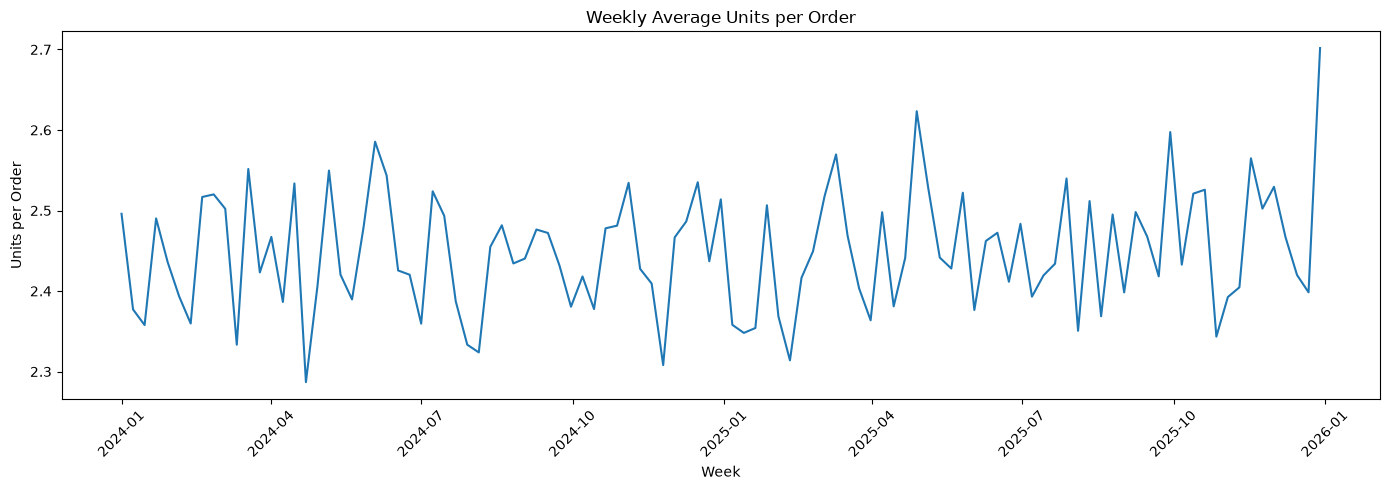

Candidate demand definitions:


order_status,Requested,Fulfilled,Delivered,Cancelled,Refunded
count,105.00,105.00,105.00,105.00,105.00
mean,582.51,387.97,387.97,178.40,16.14
std,45.24,36.44,36.44,23.52,6.83
min,308.00,166.00,166.00,126.00,3.00
25%,561.00,369.00,369.00,161.00,11.00
50%,581.00,389.00,389.00,178.00,16.00
75%,606.00,406.00,406.00,192.00,22.00
max,668.00,476.00,476.00,233.00,33.00



Weekly status shares:


order_status,Fulfilled_share,Cancelled_share,Refunded_share
count,105.00,105.00,105.00
mean,0.67,0.31,0.03
std,0.03,0.03,0.01
min,0.54,0.24,0.01
25%,0.64,0.28,0.02
50%,0.67,0.30,0.03
75%,0.69,0.33,0.04
max,0.73,0.43,0.05


,mean,std,min,max
order_status,,,,
Fulfilled_share,0.67,0.03,0.54,0.73
Cancelled_share,0.31,0.03,0.24,0.43
Refunded_share,0.03,0.01,0.01,0.05


...

MAE         RMSE       
                         mean median  mean median
baseline                                         
Moving Average - 4 Weeks 6.97   6.82  8.44   8.41
Naive-1                  8.69   7.37 10.23   8.94

baseline,Moving Average - 4 Weeks,Naive-1
product,,
Air Fryer,5.70,10.13
Backpack,7.43,9.20
Blender,6.28,6.87
Bluetooth Speaker,8.78,12.87
Body Lotion,5.12,8.20
Cookware Set,5.63,6.27
Desk Lamp,5.45,5.33
Dumbbell Set,8.02,17.60
Electric Kettle,6.82,12.33


Training weeks: 74
Validation weeks: 15

Products represented in training: 30
Products represented in validation: 30

Validation period: 2025-06-02 00:00:00 to 2025-09-08 00:00:00


,Candidate_Target,Definition,Business_Interpretation,Total_Units,Weekly_Mean,Weekly_Std
0,Requested weekly units,Sum quantity across all orders,Customer-requested unit demand,61164,582.51,45.24
1,Delivered weekly units,Sum quantity for Delivered orders only,Fulfilled/sold unit demand,40737,387.97,36.44



MODEL B VERIFICATION COMPLETE

The results above should now be used to determine:

1. Whether 'weekly product-level units' is the correct forecasting grain.
2. Whether Requested or Fulfilled units is the primary demand target.
3. Whether a 1-week-ahead forecast is adequately supported.
4. Whether historical demand contains usable temporal signal.
5. Which naive baseline should be retained before ML benchmarking.

No final target has been selected automatically.



In [ ]:
# ============================================================
# MODEL B — TARGET AND FORECASTING FORMULATION VERIFICATION
# ============================================================
# Purpose:
# Determine the most defensible:
#   1. demand definition,
#   2. forecasting granularity,
#   3. forecasting horizon,
#   4. historical signal available to forecast,
#   5. baseline feasibility.
#
# This is still analysis only.
# No ML model is trained.
# No source data is modified.
# ============================================================


# ------------------------------------------------------------
# 1. VERIFY THAT QUANTITY AND ORDER COUNT ARE RELATED
# ------------------------------------------------------------
# If weekly quantity is almost entirely explained by order count,
# quantity forecasting may effectively be order-volume forecasting.
# That is not automatically bad, but it must be understood.

weekly_orders_quantity = model_b.groupby("week").agg(
    orders=("order_id", "size"), total_quantity=("quantity", "sum")
)

print("Weekly correlation between order count and total quantity:")
print(weekly_orders_quantity["orders"].corr(weekly_orders_quantity["total_quantity"]))

display(weekly_orders_quantity.describe())

# Product-level relationship
product_week_orders_quantity = model_b.groupby(["week", "product"]).agg(
    orders=("order_id", "size"), quantity=("quantity", "sum")
)

print("\nProduct-week correlation between order count and quantity:")
print(
    product_week_orders_quantity["orders"].corr(
        product_week_orders_quantity["quantity"]
    )
)


# ------------------------------------------------------------
# 2. VERIFY AVERAGE QUANTITY PER ORDER OVER TIME
# ------------------------------------------------------------

weekly_orders_quantity["avg_units_per_order"] = (
    weekly_orders_quantity["total_quantity"] / weekly_orders_quantity["orders"]
)

print("\nWeekly average units per order:")
display(weekly_orders_quantity["avg_units_per_order"].describe())

plt.figure(figsize=(14, 5))

plt.plot(weekly_orders_quantity.index, weekly_orders_quantity["avg_units_per_order"])

plt.title("Weekly Average Units per Order")
plt.xlabel("Week")
plt.ylabel("Units per Order")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. COMPARE POSSIBLE DEFINITIONS OF DEMAND OVER TIME
# ------------------------------------------------------------
# Candidate definitions:
# A. Requested demand = all ordered units
# B. Fulfilled demand = Delivered units
# C. Delivered + Refunded is deliberately NOT treated as
#    fulfilled demand because refunded units were not retained
#    as successfully fulfilled sales without further evidence.

status_weekly = (
    model_b.groupby(["week", "order_status"])
    .agg(orders=("order_id", "size"), quantity=("quantity", "sum"))
    .reset_index()
)

weekly_status_quantity = status_weekly.pivot(
    index="week", columns="order_status", values="quantity"
).fillna(0)

for col in ["Delivered", "Cancelled", "Refunded"]:
    if col not in weekly_status_quantity.columns:
        weekly_status_quantity[col] = 0

weekly_status_quantity["Requested"] = (
    weekly_status_quantity["Delivered"]
    + weekly_status_quantity["Cancelled"]
    + weekly_status_quantity["Refunded"]
)

weekly_status_quantity["Fulfilled"] = weekly_status_quantity["Delivered"]

weekly_status_quantity["Cancelled_share"] = (
    weekly_status_quantity["Cancelled"] / weekly_status_quantity["Requested"]
)

weekly_status_quantity["Refunded_share"] = (
    weekly_status_quantity["Refunded"] / weekly_status_quantity["Requested"]
)

weekly_status_quantity["Fulfilled_share"] = (
    weekly_status_quantity["Fulfilled"] / weekly_status_quantity["Requested"]
)

print("Candidate demand definitions:")
display(
    weekly_status_quantity[
        ["Requested", "Fulfilled", "Delivered", "Cancelled", "Refunded"]
    ].describe()
)

print("\nWeekly status shares:")
display(
    weekly_status_quantity[
        ["Fulfilled_share", "Cancelled_share", "Refunded_share"]
    ].describe()
)


# ------------------------------------------------------------
# 4. CHECK WHETHER STATUS COMPOSITION IS STABLE OVER TIME
# ------------------------------------------------------------
# If the Delivered/Cancelled/Refunded proportions are almost
# constant every week, the requested-vs-fulfilled distinction
# may be structurally determined by the synthetic dataset.

status_share_variation = pd.DataFrame(
    {
        "mean": weekly_status_quantity[
            ["Fulfilled_share", "Cancelled_share", "Refunded_share"]
        ].mean(),
        "std": weekly_status_quantity[
            ["Fulfilled_share", "Cancelled_share", "Refunded_share"]
        ].std(),
        "min": weekly_status_quantity[
            ["Fulfilled_share", "Cancelled_share", "Refunded_share"]
        ].min(),
        "max": weekly_status_quantity[
            ["Fulfilled_share", "Cancelled_share", "Refunded_share"]
        ].max(),
    }
)

display(status_share_variation)


# ------------------------------------------------------------
# 5. RELATIONSHIP BETWEEN REQUESTED AND FULFILLED DEMAND
# ------------------------------------------------------------

print("\nCorrelation between weekly requested and fulfilled quantity:")
print(weekly_status_quantity["Requested"].corr(weekly_status_quantity["Fulfilled"]))

print("\nCorrelation between weekly cancelled and requested quantity:")
print(weekly_status_quantity["Cancelled"].corr(weekly_status_quantity["Requested"]))

print("\nCorrelation between weekly refunded and requested quantity:")
print(weekly_status_quantity["Refunded"].corr(weekly_status_quantity["Requested"]))


# ------------------------------------------------------------
# 6. PRODUCT-LEVEL REQUESTED VS FULFILLED DEMAND
# ------------------------------------------------------------

product_status = (
    model_b.groupby(["product", "order_status"])
    .agg(orders=("order_id", "size"), quantity=("quantity", "sum"))
    .reset_index()
)

product_status_quantity = product_status.pivot(
    index="product", columns="order_status", values="quantity"
).fillna(0)

for col in ["Delivered", "Cancelled", "Refunded"]:
    if col not in product_status_quantity.columns:
        product_status_quantity[col] = 0

product_status_quantity["Requested"] = (
    product_status_quantity["Delivered"]
    + product_status_quantity["Cancelled"]
    + product_status_quantity["Refunded"]
)

product_status_quantity["Fulfilled"] = product_status_quantity["Delivered"]

product_status_quantity["Fulfillment_rate"] = (
    product_status_quantity["Fulfilled"] / product_status_quantity["Requested"]
)

display(product_status_quantity.sort_values("Requested", ascending=False))


# ------------------------------------------------------------
# 7. DETERMINE THE BEST TEMPORAL GRANULARITY
# ------------------------------------------------------------
# Daily may be too sparse at individual product level.
# Monthly has only 24 observations.
# Weekly is the principal candidate.

daily_product = model_b.groupby([model_b["order_date"].dt.normalize(), "product"]).agg(
    orders=("order_id", "size"), quantity=("quantity", "sum")
)

daily_product_index = pd.MultiIndex.from_product(
    [
        pd.date_range(
            model_b["order_date"].min(), model_b["order_date"].max(), freq="D"
        ),
        model_b["product"].dropna().unique(),
    ],
    names=["date", "product"],
)

daily_product_complete = daily_product.reindex(daily_product_index, fill_value=0)

daily_zero_rate = (daily_product_complete["quantity"] == 0).mean()

print("Daily product-level zero-demand rate:", daily_zero_rate * 100, "%")


# Weekly zero rate was already calculated above.
weekly_zero_rate = (
    weekly_sparsity["zero_weeks"].sum() / weekly_sparsity["total_weeks"].sum()
)

print("Weekly product-level zero-demand rate:", weekly_zero_rate * 100, "%")


# Monthly product-level series
monthly_product = model_b.groupby(["month", "product"]).agg(
    orders=("order_id", "size"), quantity=("quantity", "sum")
)

print("\nNumber of monthly periods available per product:", model_b["month"].nunique())


# ------------------------------------------------------------
# 8. CHECK TEMPORAL AUTOCORRELATION
# ------------------------------------------------------------
# Forecasting requires some relationship between past and future.
# Examine lag-1, lag-2, lag-4, lag-13, and lag-52 correlations.
# Lag 52 is annual seasonality and is only a weak diagnostic
# because we have only about two years of weekly data.

weekly_product_complete = weekly_demand.pivot(
    index="week", columns="product", values="demand"
).sort_index()

lag_results = []

for product in weekly_product_complete.columns:

    series = weekly_product_complete[product]

    for lag in [1, 2, 4, 13, 26, 52]:

        valid = pd.concat([series, series.shift(lag)], axis=1).dropna()

        if len(valid) >= 10:
            correlation = valid.iloc[:, 0].corr(valid.iloc[:, 1])
        else:
            correlation = np.nan

        lag_results.append(
            {
                "product": product,
                "lag_weeks": lag,
                "autocorrelation": correlation,
                "pairs": len(valid),
            }
        )

lag_autocorrelation = pd.DataFrame(lag_results)

print("Median autocorrelation by lag:")
display(
    lag_autocorrelation.groupby("lag_weeks")["autocorrelation"].agg(
        median="median", mean="mean", minimum="min", maximum="max"
    )
)


# ------------------------------------------------------------
# 9. SHOW PRODUCT-LEVEL LAG-1 DISTRIBUTION
# ------------------------------------------------------------

lag1 = lag_autocorrelation[lag_autocorrelation["lag_weeks"] == 1].sort_values(
    "autocorrelation"
)

display(lag1)


# ------------------------------------------------------------
# 10. CHECK WEEKLY DEMAND VARIATION BY PRODUCT
# ------------------------------------------------------------

product_variation = weekly_product_complete.agg(["mean", "std", "min", "max"]).T

product_variation["cv"] = product_variation["std"] / product_variation["mean"]

display(product_variation.sort_values("cv", ascending=False))


# ------------------------------------------------------------
# 11. NAIVE FORECASTING BASELINES
# ------------------------------------------------------------
# This is still not ML.
#
# We test:
#   Naive-1: next week = previous week
#   Moving-average-4: next week = mean of previous 4 weeks
#
# The purpose is to determine whether the historical signal
# can support a meaningful forecasting exercise.
#
# We deliberately evaluate on the validation period only.
# The final test period remains untouched.

forecast_data = weekly_product_complete.copy()

forecast_train_end = pd.Timestamp("2025-05-26")
forecast_validation_end = pd.Timestamp("2025-09-12")

train_series = forecast_data[forecast_data.index <= forecast_train_end]

validation_series = forecast_data[
    (forecast_data.index > forecast_train_end)
    & (forecast_data.index <= forecast_validation_end)
]


def mae(actual, predicted):
    return np.mean(np.abs(actual - predicted))


def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))


baseline_results = []

for product in forecast_data.columns:

    train = train_series[product]
    validation = validation_series[product]

    # Last-observation naive
    last_value = train.iloc[-1]

    naive_predictions = pd.Series(last_value, index=validation.index)

    baseline_results.append(
        {
            "product": product,
            "baseline": "Naive-1",
            "MAE": mae(validation, naive_predictions),
            "RMSE": rmse(validation, naive_predictions),
        }
    )

    # Four-week moving average
    rolling_mean = train.tail(4).mean()

    moving_predictions = pd.Series(rolling_mean, index=validation.index)

    baseline_results.append(
        {
            "product": product,
            "baseline": "Moving Average - 4 Weeks",
            "MAE": mae(validation, moving_predictions),
            "RMSE": rmse(validation, moving_predictions),
        }
    )

baseline_results = pd.DataFrame(baseline_results)

display(baseline_results.groupby("baseline")[["MAE", "RMSE"]].agg(["mean", "median"]))


# ------------------------------------------------------------
# 12. BASELINE COMPARISON BY PRODUCT
# ------------------------------------------------------------

baseline_comparison = baseline_results.pivot(
    index="product", columns="baseline", values="MAE"
)

display(baseline_comparison)


# ------------------------------------------------------------
# 13. CHECK WHETHER THE DATA SUPPORTS A 1-WEEK-AHEAD TARGET
# ------------------------------------------------------------

print("Training weeks:", len(train_series))
print("Validation weeks:", len(validation_series))

print("\nProducts represented in training:", train_series.shape[1])

print("Products represented in validation:", validation_series.shape[1])

print(
    "\nValidation period:",
    validation_series.index.min(),
    "to",
    validation_series.index.max(),
)


# ------------------------------------------------------------
# 14. FINAL TARGET-DECISION EVIDENCE TABLE
# ------------------------------------------------------------

target_evidence = pd.DataFrame(
    {
        "Candidate_Target": ["Requested weekly units", "Delivered weekly units"],
        "Definition": [
            "Sum quantity across all orders",
            "Sum quantity for Delivered orders only",
        ],
        "Business_Interpretation": [
            "Customer-requested unit demand",
            "Fulfilled/sold unit demand",
        ],
        "Total_Units": [
            weekly_status_quantity["Requested"].sum(),
            weekly_status_quantity["Fulfilled"].sum(),
        ],
        "Weekly_Mean": [
            weekly_status_quantity["Requested"].mean(),
            weekly_status_quantity["Fulfilled"].mean(),
        ],
        "Weekly_Std": [
            weekly_status_quantity["Requested"].std(),
            weekly_status_quantity["Fulfilled"].std(),
        ],
    }
)

display(target_evidence)


# ------------------------------------------------------------
# 15. DO NOT AUTOMATICALLY CHOOSE THE TARGET
# ------------------------------------------------------------
print("""
MODEL B VERIFICATION COMPLETE

The results above should now be used to determine:

1. Whether 'weekly product-level units' is the correct forecasting grain.
2. Whether Requested or Fulfilled units is the primary demand target.
3. Whether a 1-week-ahead forecast is adequately supported.
4. Whether historical demand contains usable temporal signal.
5. Which naive baseline should be retained before ML benchmarking.

No final target has been selected automatically.
""")

In [35]:
# ============================================================
# MODEL B — FORECASTING DATASET CONSTRUCTION
# ============================================================
# Final candidate formulation:
#
#   Prediction unit: Product × Week
#   Forecast horizon: 1 week ahead
#   Primary target: fulfilled/delivered units in the next week
#
# Important:
# - No model training in this section.
# - No source CSV modification.
# - Last incomplete calendar week is excluded.
# - Historical features are strictly lagged / known before target week.
# ============================================================


# ------------------------------------------------------------
# 0. VERIFY REQUIRED OBJECTS
# ------------------------------------------------------------

required_objects = [
    "model_b"
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise RuntimeError(
            f"Required object '{obj_name}' is not available. "
            "Run the earlier Model B audit cells first."
        )

required_columns = [
    "order_date",
    "order_timestamp",
    "product",
    "category",
    "quantity",
    "order_status",
    "unit_price",
    "discount_percent"
]

missing_columns = [
    col for col in required_columns
    if col not in model_b.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required Model B columns: {missing_columns}"
    )

print("Model B input verification passed.")

Model B input verification passed.


In [36]:
# ------------------------------------------------------------
# 1. DEFINE COMPLETE WEEKLY CALENDAR
# ------------------------------------------------------------
# The raw dataset ends on 2025-12-31.
# Its final pandas week begins 2025-12-29, but that week contains
# only Monday-Wednesday and is therefore incomplete.
#
# We exclude that partial terminal week from the forecasting target.

model_b_work = model_b.copy()

model_b_work["order_date"] = pd.to_datetime(
    model_b_work["order_date"],
    errors="raise"
)

model_b_work["week"] = (
    model_b_work["order_date"]
    .dt.to_period("W")
    .dt.start_time
)

first_week = model_b_work["week"].min()
last_observed_week = model_b_work["week"].max()

# Last complete Monday-Sunday week.
last_complete_week = last_observed_week - pd.Timedelta(days=7)

complete_weeks = pd.date_range(
    start=first_week,
    end=last_complete_week,
    freq="7D"
)

print("First week:", first_week)
print("Last observed week:", last_observed_week)
print("Last complete week:", last_complete_week)
print("Complete weeks available:", len(complete_weeks))

First week: 2024-01-01 00:00:00
Last observed week: 2025-12-29 00:00:00
Last complete week: 2025-12-22 00:00:00
Complete weeks available: 104


In [37]:
# ------------------------------------------------------------
# 2. VERIFY WEEK COMPLETENESS
# ------------------------------------------------------------

week_day_counts = (
    model_b_work
    .groupby("week")["order_date"]
    .nunique()
    .sort_index()
)

complete_week_check = week_day_counts.loc[
    week_day_counts.index.isin(complete_weeks)
]

print("Minimum observed calendar days in complete weeks:",
      complete_week_check.min())

print("Maximum observed calendar days in complete weeks:",
      complete_week_check.max())

incomplete_weeks_inside_range = complete_week_check[
    complete_week_check != 7
]

print(
    "Incomplete weeks inside retained range:",
    len(incomplete_weeks_inside_range)
)

if len(incomplete_weeks_inside_range) > 0:
    display(incomplete_weeks_inside_range)

if (
    complete_week_check.min() != 7
    or len(incomplete_weeks_inside_range) > 0
):
    raise ValueError(
        "A retained forecasting week is incomplete. "
        "Do not continue until the weekly calendar is corrected."
    )

print("All retained weeks contain all 7 calendar days.")

Minimum observed calendar days in complete weeks: 7
Maximum observed calendar days in complete weeks: 7
Incomplete weeks inside retained range: 0
All retained weeks contain all 7 calendar days.


In [40]:
# ------------------------------------------------------------
# 3. RESTRICT TRANSACTIONS TO COMPLETE WEEKS
# ------------------------------------------------------------

model_b_complete = model_b_work[
    model_b_work["week"].isin(complete_weeks)
].copy()

print("Original transaction rows:", len(model_b_work))
print("Rows in complete weeks:", len(model_b_complete))
print("Excluded terminal partial-week rows:",
      len(model_b_work) - len(model_b_complete))
# ------------------------------------------------------------
# 4. AGGREGATE WEEKLY PRODUCT-LEVEL OBSERVATIONS
# ------------------------------------------------------------
# We construct several historical quantities.
#
# Primary target later:
#     delivered_quantity
#
# Historical explanatory quantities:
#     requested_quantity
#     cancelled_quantity
#     refunded_quantity
#
# Historical operational variables:
#     orders
#     average unit price
#     average discount
#
# These are not yet "features"; they become features only after
# being shifted so that they precede the future target week.

weekly_product_raw = (
    model_b_complete
    .groupby(["week", "product", "category"], as_index=False)
    .agg(
        orders=("order_id", "size"),
        requested_quantity=("quantity", "sum"),

        delivered_quantity=(
            "quantity",
            lambda x: x[
                model_b_complete.loc[x.index, "order_status"]
                .eq("Delivered")
            ].sum()
        ),

        cancelled_quantity=(
            "quantity",
            lambda x: x[
                model_b_complete.loc[x.index, "order_status"]
                .eq("Cancelled")
            ].sum()
        ),

        refunded_quantity=(
            "quantity",
            lambda x: x[
                model_b_complete.loc[x.index, "order_status"]
                .eq("Refunded")
            ].sum()
        ),

        average_unit_price=("unit_price", "mean"),
        average_discount_percent=("discount_percent", "mean")
    )
)

display(weekly_product_raw.head(20))
print("Observed product-week rows:", len(weekly_product_raw))
# ------------------------------------------------------------
# 5. BUILD THE COMPLETE PRODUCT × WEEK PANEL
# ------------------------------------------------------------
# Every product must have one row for every retained week.
#
# Missing product-week demand is interpreted as zero demand,
# not as a missing observation.

products = (
    model_b_complete["product"]
    .dropna()
    .drop_duplicates()
    .sort_values()
    .tolist()
)

product_category = (
    model_b_complete[
        ["product", "category"]
    ]
    .drop_duplicates("product")
    .set_index("product")["category"]
)

full_panel_index = pd.MultiIndex.from_product(
    [complete_weeks, products],
    names=["week", "product"]
)

weekly_panel = (
    weekly_product_raw
    .set_index(["week", "product"])
    .reindex(full_panel_index)
    .reset_index()
)

weekly_panel["category"] = (
    weekly_panel["product"]
    .map(product_category)
)

quantity_columns = [
    "orders",
    "requested_quantity",
    "delivered_quantity",
    "cancelled_quantity",
    "refunded_quantity"
]

for col in quantity_columns:
    weekly_panel[col] = (
        weekly_panel[col]
        .fillna(0)
    )

# Counts/quantities can legitimately be zero.
# Price/discount remain missing when there were no transactions
# in that product-week because there was no observed price to average.
print("Complete panel shape:", weekly_panel.shape)
print("Expected rows:",
      len(complete_weeks) * len(products))
# ------------------------------------------------------------
# 6. VERIFY PANEL COMPLETENESS
# ------------------------------------------------------------

expected_rows = len(complete_weeks) * len(products)

assert len(weekly_panel) == expected_rows

assert weekly_panel[
    ["week", "product"]
].duplicated().sum() == 0

print("Expected rows:", expected_rows)
print("Actual rows:", len(weekly_panel))
print(
    "Duplicate product-week rows:",
    weekly_panel[["week", "product"]].duplicated().sum()
)

print(
    "Products:",
    weekly_panel["product"].nunique()
)

print(
    "Weeks:",
    weekly_panel["week"].nunique()
)

display(
    weekly_panel[
        [
            "week",
            "product",
            "category",
            "orders",
            "requested_quantity",
            "delivered_quantity",
            "cancelled_quantity",
            "refunded_quantity"
        ]
    ].head(30)
)
# ------------------------------------------------------------
# 7. CHECK WEEKLY TARGET QUALITY
# ------------------------------------------------------------
# Primary target candidate:
#
# delivered_quantity
#
# This means:
# "number of units belonging to Delivered orders placed
# during the forecast week."

print("Delivered quantity missing:",
      weekly_panel["delivered_quantity"].isna().sum())

print("Delivered quantity negative:",
      (weekly_panel["delivered_quantity"] < 0).sum())

print("Delivered quantity zero:",
      (weekly_panel["delivered_quantity"] == 0).sum())

print("\nDelivered weekly quantity statistics:")
display(
    weekly_panel["delivered_quantity"].describe()
)

print("\nRequested weekly quantity statistics:")
display(
    weekly_panel["requested_quantity"].describe()
)
# ------------------------------------------------------------
# 8. CREATE FUTURE TARGET
# ------------------------------------------------------------
# Each row represents:
#
#   feature_week = information available through this week
#   forecast_week = the next week
#   target = delivered quantity during forecast_week
#
# shift(-1) within each product creates the one-week-ahead target.

weekly_panel = weekly_panel.sort_values(
    ["product", "week"]
).reset_index(drop=True)

weekly_panel.groupby("product")["requested_quantity"].shift(-1)

# weekly_panel["target_delivered_quantity"] = (
#     weekly_panel
#     .groupby("product")["delivered_quantity"]
#     .shift(-1)
# )

weekly_panel["forecast_week"] = (
    weekly_panel["week"] + pd.Timedelta(days=7)
)

print(
    "Rows with one-week-ahead target:",
    weekly_panel["requested_quantity"].notna().sum()
)

print(
    "Rows without one-week-ahead target:",
    weekly_panel["requested_quantity"].isna().sum()
)
# ------------------------------------------------------------
# 9. CREATE HISTORICAL LAG FEATURES
# ------------------------------------------------------------
# Every lag is generated BEFORE the target week.
#
# Example:
#
# feature_week = 2025-06-02
# lag_1        = demand during 2025-06-02
# target       = demand during 2025-06-09
#
# Therefore the target itself is never used as a lag.

history_columns = [
    "delivered_quantity",
    "requested_quantity",
    "cancelled_quantity",
    "refunded_quantity",
    "orders",
    "average_unit_price",
    "average_discount_percent"
]

lag_values = [1, 2, 4, 8, 13]

for col in history_columns:
    for lag in lag_values:

        weekly_panel[f"{col}_lag_{lag}"] = (
            weekly_panel
            .groupby("product")[col]
            .shift(lag)
        )

print("Lag features created.")
# ------------------------------------------------------------
# 10. CREATE LEAKAGE-SAFE ROLLING FEATURES
# ------------------------------------------------------------
# Critical:
#
# shift(1) happens BEFORE rolling().
#
# Therefore a rolling statistic for feature week T uses:
#     T-1, T-2, ...
#
# and does not include T or anything from the future.

rolling_columns = [
    "delivered_quantity",
    "requested_quantity",
    "orders"
]

rolling_windows = [4, 8, 13]

for col in rolling_columns:

    historical_series = (
        weekly_panel
        .groupby("product")[col]
        .shift(1)
    )

    for window in rolling_windows:

        weekly_panel[
            f"{col}_rolling_mean_{window}"
        ] = (
            historical_series
            .groupby(weekly_panel["product"])
            .rolling(window=window, min_periods=window)
            .mean()
            .reset_index(level=0, drop=True)
            .sort_index()
        )

        if col == "delivered_quantity":
            weekly_panel[
                f"{col}_rolling_std_{window}"
            ] = (
                historical_series
                .groupby(weekly_panel["product"])
                .rolling(window=window, min_periods=window)
                .std()
                .reset_index(level=0, drop=True)
                .sort_index()
            )

print("Rolling historical features created.")
# ------------------------------------------------------------
# 11. CREATE HISTORICAL RATE FEATURES
# ------------------------------------------------------------
# Rates are based only on the historical feature week and then
# lagged by one week relative to the forecast target.

weekly_panel["historical_fulfillment_rate"] = (
    weekly_panel["delivered_quantity"]
    / weekly_panel["requested_quantity"].replace(0, np.nan)
)

weekly_panel["historical_cancellation_rate"] = (
    weekly_panel["cancelled_quantity"]
    / weekly_panel["requested_quantity"].replace(0, np.nan)
)

weekly_panel["historical_refund_rate"] = (
    weekly_panel["refunded_quantity"]
    / weekly_panel["requested_quantity"].replace(0, np.nan)
)

for col in [
    "historical_fulfillment_rate",
    "historical_cancellation_rate",
    "historical_refund_rate"
]:

    weekly_panel[f"{col}_lag_1"] = (
        weekly_panel
        .groupby("product")[col]
        .shift(1)
    )

    weekly_panel[f"{col}_rolling_mean_4"] = (
        weekly_panel
        .groupby("product")[col]
        .shift(1)
        .groupby(weekly_panel["product"])
        .rolling(window=4, min_periods=4)
        .mean()
        .reset_index(level=0, drop=True)
        .sort_index()
    )

print("Historical rate features created.")
# ------------------------------------------------------------
# 12. CREATE FORECAST-WEEK CALENDAR FEATURES
# ------------------------------------------------------------
# These are legitimate because calendar information for the
# future week is known before the week occurs.

weekly_panel["forecast_year"] = (
    weekly_panel["forecast_week"].dt.year
)

weekly_panel["forecast_month"] = (
    weekly_panel["forecast_week"].dt.month
)

weekly_panel["forecast_quarter"] = (
    weekly_panel["forecast_week"].dt.quarter
)

weekly_panel["forecast_week_of_year"] = (
    weekly_panel["forecast_week"].dt.isocalendar().week.astype(int)
)

# Cyclical representation of the position within the year.
weekly_panel["forecast_week_sin"] = (
    np.sin(
        2 * np.pi
        * weekly_panel["forecast_week_of_year"]
        / 52
    )
)

weekly_panel["forecast_week_cos"] = (
    np.cos(
        2 * np.pi
        * weekly_panel["forecast_week_of_year"]
        / 52
    )
)

print("Forecast calendar features created.")
# ------------------------------------------------------------
# 13. DEFINE THE CANDIDATE MODEL B DATASET
# ------------------------------------------------------------
# We deliberately do not include:
# - order_id
# - customer_id
# - target-week quantities
# - future order status
# - actual_delivery_days
# - customer_rating
#
# Product and category are static/contextual variables at this
# forecasting grain.
#
# Price and discount are represented through historical values
# only, not future-week averages.

candidate_feature_columns = [

    # Static/contextual
    "product",
    "category",

    # Forecast-week calendar
    "forecast_month",
    "forecast_quarter",
    "forecast_week_of_year",
    "forecast_week_sin",
    "forecast_week_cos",

    # Historical lag features
    "delivered_quantity_lag_1",
    "delivered_quantity_lag_2",
    "delivered_quantity_lag_4",
    "delivered_quantity_lag_8",
    "delivered_quantity_lag_13",

    "requested_quantity_lag_1",
    "requested_quantity_lag_2",
    "requested_quantity_lag_4",
    "requested_quantity_lag_8",
    "requested_quantity_lag_13",

    "cancelled_quantity_lag_1",
    "cancelled_quantity_lag_2",
    "cancelled_quantity_lag_4",
    "cancelled_quantity_lag_8",
    "cancelled_quantity_lag_13",

    "refunded_quantity_lag_1",
    "refunded_quantity_lag_2",
    "refunded_quantity_lag_4",
    "refunded_quantity_lag_8",
    "refunded_quantity_lag_13",

    "orders_lag_1",
    "orders_lag_2",
    "orders_lag_4",
    "orders_lag_8",
    "orders_lag_13",

    "average_unit_price_lag_1",
    "average_unit_price_lag_2",
    "average_unit_price_lag_4",
    "average_unit_price_lag_8",
    "average_unit_price_lag_13",

    "average_discount_percent_lag_1",
    "average_discount_percent_lag_2",
    "average_discount_percent_lag_4",
    "average_discount_percent_lag_8",
    "average_discount_percent_lag_13",

    # Historical rolling statistics
    "delivered_quantity_rolling_mean_4",
    "delivered_quantity_rolling_mean_8",
    "delivered_quantity_rolling_mean_13",

    "delivered_quantity_rolling_std_4",
    "delivered_quantity_rolling_std_8",
    "delivered_quantity_rolling_std_13",

    "requested_quantity_rolling_mean_4",
    "requested_quantity_rolling_mean_8",
    "requested_quantity_rolling_mean_13",

    "orders_rolling_mean_4",
    "orders_rolling_mean_8",
    "orders_rolling_mean_13",

    # Historical status rates
    "historical_fulfillment_rate_lag_1",
    "historical_fulfillment_rate_rolling_mean_4",

    "historical_cancellation_rate_lag_1",
    "historical_cancellation_rate_rolling_mean_4",

    "historical_refund_rate_lag_1",
    "historical_refund_rate_rolling_mean_4",
]

target_column = "requested_quantity"

forecast_dataset = weekly_panel[
    [
        "week",
        "forecast_week",
        *candidate_feature_columns,
        target_column
    ]
].copy()

print("Candidate forecast dataset shape:",
      forecast_dataset.shape)

display(forecast_dataset.head(20))
# ------------------------------------------------------------
# 14. REMOVE ROWS WITHOUT ENOUGH HISTORY
# ------------------------------------------------------------
# lag_13 and rolling_13 require sufficient historical weeks.
#
# These early rows cannot legitimately contain all requested
# historical features, so they are excluded from the modeling
# dataset rather than imputed with invented history.

required_history_columns = [
    "delivered_quantity_lag_13",
    "requested_quantity_lag_13",
    "cancelled_quantity_lag_13",
    "refunded_quantity_lag_13",
    "orders_lag_13",
    "delivered_quantity_rolling_mean_13",
    "delivered_quantity_rolling_std_13",
    "requested_quantity_rolling_mean_13",
    "orders_rolling_mean_13",
]

before_history_filter = len(forecast_dataset)

forecast_dataset = forecast_dataset.dropna(
    subset=required_history_columns + [target_column]
).copy()

after_history_filter = len(forecast_dataset)

print("Rows before history filter:",
      before_history_filter)

print("Rows after history filter:",
      after_history_filter)

print("Rows removed:",
      before_history_filter - after_history_filter)
# ------------------------------------------------------------
# 15. LEAKAGE CHECK 1 — TARGET ALIGNMENT
# ------------------------------------------------------------
# Every row must satisfy:
#
# forecast_week = feature_week + 7 days

target_alignment_check = (
    forecast_dataset["forecast_week"]
    == forecast_dataset["week"] + pd.Timedelta(days=7)
)

print("Target alignment failures:",
      (~target_alignment_check).sum())

if (~target_alignment_check).any():
    raise AssertionError(
        "Forecast-week alignment failed."
    )

print("Target alignment verified.")
# ------------------------------------------------------------
# 16. LEAKAGE CHECK 2 — FORECAST PERIOD MUST BE IN THE FUTURE
# ------------------------------------------------------------

print(
    "Rows where forecast week is not after feature week:",
    (
        forecast_dataset["forecast_week"]
        <= forecast_dataset["week"]
    ).sum()
)

if (
    forecast_dataset["forecast_week"]
    <= forecast_dataset["week"]
).any():
    raise AssertionError(
        "Forecast period is not strictly after feature period."
    )

print("Forecast chronology verified.")
# ------------------------------------------------------------
# 17. LEAKAGE CHECK 3 — TARGET IS NOT IN FEATURE LIST
# ------------------------------------------------------------

if target_column in candidate_feature_columns:
    raise AssertionError(
        "Target column accidentally appears in feature list."
    )

print("Target is not included as a feature.")
# ------------------------------------------------------------
# 18. LEAKAGE CHECK 4 — POST-OUTCOME / IDENTIFIER COLUMNS
# ------------------------------------------------------------

forbidden_columns = [
    "order_id",
    "customer_id",
    "order_timestamp",
    "order_date",
    "order_status",
    "actual_delivery_days",
    "customer_rating",
    "total_amount",
    "gross_amount",
    "discount_amount",
]

forbidden_present = [
    col for col in forbidden_columns
    if col in candidate_feature_columns
]

print("Forbidden feature columns found:",
      forbidden_present)

if forbidden_present:
    raise AssertionError(
        "Forbidden/leakage-prone columns are present."
    )

print("Identifier and post-outcome leakage check passed.")
# ------------------------------------------------------------
# 19. LEAKAGE CHECK 5 — VERIFY LAG FEATURES
# ------------------------------------------------------------
# Check a few randomly selected products manually through
# deterministic examples.

sample_product = forecast_dataset["product"].iloc[0]

sample = (
    forecast_dataset[
        forecast_dataset["product"] == sample_product
    ]
    .sort_values("week")
    .head(5)
)

display(
    sample[
        [
            "week",
            "forecast_week",
            "delivered_quantity_lag_1",
            "delivered_quantity_lag_2",
            "delivered_quantity_lag_4",
            target_column
        ]
    ]
)

print(
    f"""
For product: {sample_product}

Interpretation:
- lag_1 = delivered demand in the feature week
- lag_2 = delivered demand two weeks before the forecast week
- lag_4 = delivered demand four weeks before the forecast week
- target = delivered demand in forecast_week

The target must therefore occur strictly after every lagged
historical observation.
"""
)
# ------------------------------------------------------------
# 20. LEAKAGE CHECK 6 — FINAL FEATURE AVAILABILITY REVIEW
# ------------------------------------------------------------

feature_review = pd.DataFrame({
    "feature": candidate_feature_columns
})

feature_review["status"] = "Eligible"

feature_review.loc[
    feature_review["feature"].str.contains(
        "target",
        case=False,
        regex=True
    ),
    "status"
] = "REVIEW — target reference"

feature_review.loc[
    feature_review["feature"].isin(
        [
            "actual_delivery_days",
            "customer_rating",
            "order_status",
            "total_amount",
            "gross_amount",
            "discount_amount"
        ]
    ),
    "status"
] = "REJECT — leakage/post-outcome"

display(feature_review)
# ------------------------------------------------------------
# 21. CHRONOLOGICAL DATASET SUMMARY
# ------------------------------------------------------------

print("Forecast dataset rows:", len(forecast_dataset))
print("Products:", forecast_dataset["product"].nunique())

print(
    "Feature weeks:",
    forecast_dataset["week"].min(),
    "to",
    forecast_dataset["week"].max()
)

print(
    "Forecast weeks:",
    forecast_dataset["forecast_week"].min(),
    "to",
    forecast_dataset["forecast_week"].max()
)

print(
    "Unique forecast weeks:",
    forecast_dataset["forecast_week"].nunique()
)

print(
    "Unique product-week combinations:",
    forecast_dataset[
        ["product", "forecast_week"]
    ].drop_duplicates().shape[0]
)

print(
    "Duplicate product-forecast-week rows:",
    forecast_dataset[
        ["product", "forecast_week"]
    ].duplicated().sum()
)
# ------------------------------------------------------------
# 22. PRODUCT-LEVEL FORECASTING COVERAGE
# ------------------------------------------------------------

product_forecast_coverage = (
    forecast_dataset
    .groupby("product")
    .agg(
        forecast_periods=("forecast_week", "nunique"),
        total_target_units=(target_column, "sum"),
        mean_target_units=(target_column, "mean"),
        min_target_units=(target_column, "min"),
        max_target_units=(target_column, "max")
    )
    .sort_values(
        "forecast_periods",
        ascending=True
    )
)

display(product_forecast_coverage)

print(
    "Minimum forecast periods for any product:",
    product_forecast_coverage[
        "forecast_periods"
    ].min()
)

print(
    "Maximum forecast periods for any product:",
    product_forecast_coverage[
        "forecast_periods"
    ].max()
)
# ------------------------------------------------------------
# 23. CHRONOLOGICAL SPLIT PREVIEW
# ------------------------------------------------------------
# This is a PREVIEW only.
# We will finalize the exact train/validation/test design
# before model benchmarking.

forecast_dates = (
    forecast_dataset["forecast_week"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

print("Number of forecast periods:", len(forecast_dates))

# Approximate chronological 70 / 15 / 15 period partition.
n_periods = len(forecast_dates)

train_cut = int(n_periods * 0.70)
validation_cut = int(n_periods * 0.85)

train_end_preview = forecast_dates.iloc[train_cut - 1]
validation_end_preview = forecast_dates.iloc[validation_cut - 1]

print("\nPREVIEW ONLY — not yet frozen")
print("Training through:", train_end_preview)
print(
    "Validation:",
    forecast_dates.iloc[train_cut],
    "to",
    validation_end_preview
)
print(
    "Test:",
    forecast_dates.iloc[validation_cut],
    "to",
    forecast_dates.iloc[-1]
)
# ------------------------------------------------------------
# 24. SAVE THE CANDIDATE DATASET IN MEMORY ONLY
# ------------------------------------------------------------
# We do not write a CSV yet.
#
# First inspect the results and verify that the target/features
# are correct.
#
# This is deliberately kept in memory for now.

print("Model B candidate forecasting dataset is ready in memory.")
print("Object name: forecast_dataset")
print("Target column:", target_column)
print("Number of candidate features:", len(candidate_feature_columns))

Original transaction rows: 25000
Rows in complete weeks: 24886
Excluded terminal partial-week rows: 114


,week,product,category,orders,requested_quantity,delivered_quantity,cancelled_quantity,refunded_quantity,average_unit_price,average_discount_percent
0,2024-01-01,Air Fryer,Home & Kitchen,7,16,10,6,0,"66,328.57",13.57
1,2024-01-01,Backpack,Fashion,13,34,24,3,7,"30,100.00",4.23
2,2024-01-01,Blender,Home & Kitchen,8,18,18,0,0,"27,925.00",13.75
3,2024-01-01,Bluetooth Speaker,Electronics,9,22,16,6,0,"27,444.44",6.67
4,2024-01-01,Body Lotion,Beauty & Personal Care,4,9,6,3,0,"8,525.00",8.75
5,2024-01-01,Cookware Set,Home & Kitchen,13,31,14,10,7,"76,069.23",15.77
6,2024-01-01,Desk Lamp,Home & Kitchen,12,26,22,4,0,"16,533.33",7.08
7,2024-01-01,Dumbbell Set,Sports & Fitness,10,30,20,10,0,"43,200.00",9.50
8,2024-01-01,Electric Kettle,Home & Kitchen,7,16,13,3,0,"18,500.00",12.14
9,2024-01-01,Electric Trimmer,Beauty & Personal Care,5,9,9,0,0,"17,280.00",10.00


Observed product-week rows: 3120
Complete panel shape: (3120, 10)
Expected rows: 3120
Expected rows: 3120
Actual rows: 3120
Duplicate product-week rows: 0
Products: 30
Weeks: 104


,week,product,category,orders,requested_quantity,delivered_quantity,cancelled_quantity,refunded_quantity
0,2024-01-01,Air Fryer,Home & Kitchen,7,16,10,6,0
1,2024-01-01,Backpack,Fashion,13,34,24,3,7
2,2024-01-01,Blender,Home & Kitchen,8,18,18,0,0
3,2024-01-01,Bluetooth Speaker,Electronics,9,22,16,6,0
4,2024-01-01,Body Lotion,Beauty & Personal Care,4,9,6,3,0
5,2024-01-01,Cookware Set,Home & Kitchen,13,31,14,10,7
6,2024-01-01,Desk Lamp,Home & Kitchen,12,26,22,4,0
7,2024-01-01,Dumbbell Set,Sports & Fitness,10,30,20,10,0
8,2024-01-01,Electric Kettle,Home & Kitchen,7,16,13,3,0
9,2024-01-01,Electric Trimmer,Beauty & Personal Care,5,9,9,0,0


Delivered quantity missing: 0
Delivered quantity negative: 0
Delivered quantity zero: 18

Delivered weekly quantity statistics:


...


For product: Air Fryer

Interpretation:
- lag_1 = delivered demand in the feature week
- lag_2 = delivered demand two weeks before the forecast week
- lag_4 = delivered demand four weeks before the forecast week
- target = delivered demand in forecast_week

The target must therefore occur strictly after every lagged
historical observation.



,feature,status
0,product,Eligible
1,category,Eligible
2,forecast_month,Eligible
3,forecast_quarter,Eligible
4,forecast_week_of_year,Eligible
5,forecast_week_sin,Eligible
6,forecast_week_cos,Eligible
7,delivered_quantity_lag_1,Eligible
8,delivered_quantity_lag_2,Eligible
9,delivered_quantity_lag_4,Eligible


Forecast dataset rows: 2730
Products: 30
Feature weeks: 2024-04-01 00:00:00 to 2025-12-22 00:00:00
Forecast weeks: 2024-04-08 00:00:00 to 2025-12-29 00:00:00
Unique forecast weeks: 91
Unique product-week combinations: 2730
Duplicate product-forecast-week rows: 0


,forecast_periods,total_target_units,mean_target_units,min_target_units,max_target_units
product,,,,,
Air Fryer,91,1595,17.53,7,41
Backpack,91,1972,21.67,6,48
Blender,91,1760,19.34,6,40
Bluetooth Speaker,91,2171,23.86,10,42
Body Lotion,91,1275,14.01,3,28
Cookware Set,91,1710,18.79,6,35
Desk Lamp,91,1752,19.25,4,35
Dumbbell Set,91,2012,22.11,5,51
Electric Kettle,91,1681,18.47,2,36


Minimum forecast periods for any product: 91
Maximum forecast periods for any product: 91
Number of forecast periods: 91

PREVIEW ONLY — not yet frozen
Training through: 2025-06-16 00:00:00
Validation: 2025-06-23 00:00:00 to 2025-09-22 00:00:00
Test: 2025-09-29 00:00:00 to 2025-12-29 00:00:00
Model B candidate forecasting dataset is ready in memory.
Object name: forecast_dataset
Target column: requested_quantity
Number of candidate features: 60
